In [1]:
# Cell 1: Build C2 fermionic Hamiltonian and Hermitian fermionic terms

import pandas as pd

from openfermion.chem import MolecularData
from openfermion.ops import FermionOperator
from openfermion.transforms import get_fermion_operator, normal_ordered
from openfermion.utils import hermitian_conjugated
from openfermionpyscf import run_pyscf

pd.set_option("display.max_colwidth", None)


# ------------------------------------------------------------
# Carbon dimer / C2 configuration
# ------------------------------------------------------------

C2_BOND_LENGTH = 1.243  # Angstrom, approximate C-C bond length
BASIS = "sto-3g"
MULTIPLICITY = 1
CHARGE = 0

# Full C2/STO-3G should give 20 qubits:
# Each C has 5 STO-3G spatial orbitals.
# 10 spatial orbitals * 2 spin orbitals = 20 qubits.
USE_ACTIVE_SPACE = True

# Optional active-space example:
# Freeze the two lowest occupied core-like spatial orbitals and keep valence orbitals active.
# This usually reduces C2/STO-3G from 20 qubits to 16 qubits.
OCCUPIED_INDICES = [0, 1]
ACTIVE_INDICES = [2, 3, 4, 5, 6, 7, 8, 9]

# Set this smaller, e.g. 1e-10, if tiny numerical terms clutter the graph.
TERM_ABS_TOL = 1e-12

# For large molecules, printing the full Hamiltonian can be very large.
PRINT_FULL_HAMILTONIAN = True


def format_fermion_term(term):
    if term == ():
        return "I"

    pieces = []
    for orbital, action in term:
        if action == 1:
            pieces.append(f"a_{orbital}^dagger")
        else:
            pieces.append(f"a_{orbital}")
    return " ".join(pieces)


def sort_fermion_key(term):
    return (len(term), term)


def coeff_to_str(c, digits=8):
    c = complex(c)
    if abs(c.imag) < 1e-12:
        return f"{c.real:+.{digits}f}"
    return f"{c.real:+.{digits}f}{c.imag:+.{digits}f}j"


def operator_to_string(op, digits=8):
    pieces = []

    for term, coeff in sorted(op.terms.items(), key=lambda item: sort_fermion_key(item[0])):
        pieces.append(f"{coeff_to_str(coeff, digits)} {format_fermion_term(term)}")

    if len(pieces) == 0:
        return "0"

    return " + ".join(pieces)


def dagger_term_key(term):
    """
    Return the OpenFermion key for O^dagger, where O is one monomial.
    """
    O = FermionOperator(term, 1.0)
    O_dag = normal_ordered(hermitian_conjugated(O))
    O_dag.compress(abs_tol=TERM_ABS_TOL)

    if len(O_dag.terms) != 1:
        raise ValueError(f"Expected one dagger term, got: {O_dag}")

    return next(iter(O_dag.terms.keys()))


def make_hermitian_fermionic_terms(fermion_hamiltonian, tol=TERM_ABS_TOL):
    """
    Group raw monomials into Hermitian fermionic Hamiltonian terms.

    If O is self-adjoint, keep c O.
    If O is not self-adjoint, group c O + c* O^dagger using the
    coefficients already present in the Hamiltonian.
    """
    used = set()
    hermitian_terms = []

    for term, coeff in fermion_hamiltonian.terms.items():
        if term in used:
            continue

        dag = dagger_term_key(term)

        if dag == term:
            T = FermionOperator(term, coeff)
            used.add(term)
        else:
            dag_coeff = fermion_hamiltonian.terms.get(dag, 0.0)

            T = FermionOperator(term, coeff)
            T += FermionOperator(dag, dag_coeff)

            used.add(term)
            used.add(dag)

        T = normal_ordered(T)
        T.compress(abs_tol=tol)
        hermitian_terms.append(T)

    return hermitian_terms


def infer_n_qubits_from_fermion_operator(op):
    """
    Infer the number of spin orbitals used by the FermionOperator.

    This is important for active-space Hamiltonians, where the active
    modes may be reindexed and smaller than molecule.n_qubits.
    """
    max_orbital = -1

    for term in op.terms:
        for orbital, action in term:
            max_orbital = max(max_orbital, orbital)

    return max_orbital + 1


def build_c2_geometry(c2_bond_length=C2_BOND_LENGTH):
    """
    Build linear carbon dimer geometry.

    First carbon is placed at the origin.
    Second carbon is placed on the z-axis.
    """
    geometry = [
        ("C", (0.0, 0.0, 0.0)),
        ("C", (0.0, 0.0, c2_bond_length)),
    ]

    return geometry


def build_c2_fermionic_hamiltonian(
    c2_bond_length=C2_BOND_LENGTH,
    basis=BASIS,
    multiplicity=MULTIPLICITY,
    charge=CHARGE,
    use_active_space=USE_ACTIVE_SPACE,
    occupied_indices=OCCUPIED_INDICES,
    active_indices=ACTIVE_INDICES,
):
    """
    Build a C2 fermionic Hamiltonian using OpenFermion + PySCF.

    If use_active_space=True, molecule.get_molecular_hamiltonian is called
    with occupied_indices and active_indices.
    """
    geometry = build_c2_geometry(c2_bond_length=c2_bond_length)

    molecule = MolecularData(
        geometry=geometry,
        basis=basis,
        multiplicity=multiplicity,
        charge=charge,
        description=f"C2_{c2_bond_length}",
    )

    # FCI is not required for constructing the fermionic Hamiltonian.
    molecule = run_pyscf(
        molecule,
        run_scf=True,
        run_fci=False,
    )

    if use_active_space:
        molecular_hamiltonian = molecule.get_molecular_hamiltonian(
            occupied_indices=occupied_indices,
            active_indices=active_indices,
        )
    else:
        molecular_hamiltonian = molecule.get_molecular_hamiltonian()

    fermion_hamiltonian = get_fermion_operator(molecular_hamiltonian)
    fermion_hamiltonian = normal_ordered(fermion_hamiltonian)
    fermion_hamiltonian.compress(abs_tol=TERM_ABS_TOL)

    n_qubits = infer_n_qubits_from_fermion_operator(fermion_hamiltonian)

    return molecule, fermion_hamiltonian, n_qubits


# ------------------------------------------------------------
# Build C2 fermionic Hamiltonian
# ------------------------------------------------------------

molecule, Hf, n_qubits = build_c2_fermionic_hamiltonian()
hermitian_terms = make_hermitian_fermionic_terms(Hf)

print("Molecule: C2 / Carbon dimer")
print("Basis:", BASIS)
print("C-C bond length [Angstrom]:", C2_BOND_LENGTH)
print("Use active space:", USE_ACTIVE_SPACE)
if USE_ACTIVE_SPACE:
    print("Frozen occupied spatial orbitals:", OCCUPIED_INDICES)
    print("Active spatial orbitals:", ACTIVE_INDICES)
print("Full molecule electrons:", molecule.n_electrons)
print("Full molecule spatial orbitals:", molecule.n_orbitals)
print("Full molecule spin orbitals / qubits:", molecule.n_qubits)
print("Hamiltonian spin orbitals / qubits used:", n_qubits)
print("Number of raw OpenFermion monomial terms:", len(Hf.terms))
print("Number of Hermitian fermionic terms:", len(hermitian_terms))

if PRINT_FULL_HAMILTONIAN:
    print("\n=== Full fermionic Hamiltonian H_f ===")
    print(Hf)


# ------------------------------------------------------------
# Tables
# ------------------------------------------------------------

raw_rows = []

for idx, (term, coeff) in enumerate(
    sorted(Hf.terms.items(), key=lambda item: sort_fermion_key(item[0]))
):
    raw_rows.append(
        {
            "raw_index": idx,
            "coefficient": coeff_to_str(coeff),
            "monomial": format_fermion_term(term),
            "OpenFermion_key": term,
        }
    )

raw_df = pd.DataFrame(raw_rows)

print("\n=== Raw fermionic monomials c_alpha O_alpha ===")
display(raw_df)


hermitian_rows = []

for i, T in enumerate(hermitian_terms):
    hermitian_rows.append(
        {
            "vertex": f"T_{i}",
            "number_of_monomials": len(T.terms),
            "fermionic_term": operator_to_string(T),
        }
    )

hermitian_df = pd.DataFrame(hermitian_rows)

print("\n=== Hermitian fermionic terms T_i ===")
display(hermitian_df)

Molecule: C2 / Carbon dimer
Basis: sto-3g
C-C bond length [Angstrom]: 1.243
Use active space: True
Frozen occupied spatial orbitals: [0, 1]
Active spatial orbitals: [2, 3, 4, 5, 6, 7, 8, 9]
Full molecule electrons: 12
Full molecule spatial orbitals: 10
Full molecule spin orbitals / qubits: 20
Hamiltonian spin orbitals / qubits used: 16
Number of raw OpenFermion monomial terms: 1177
Number of Hermitian fermionic terms: 657

=== Full fermionic Hamiltonian H_f ===
-57.16290883129457 [] +
-4.368820558483946 [0^ 0] +
-0.3962263107582892 [0^ 8] +
-0.614925443939968 [1^ 0^ 1 0] +
-0.06929685460206467 [1^ 0^ 3 2] +
-0.09428511318567072 [1^ 0^ 5 4] +
-0.0942851131856706 [1^ 0^ 7 6] +
0.10028101330532348 [1^ 0^ 8 1] +
-0.10028101330532348 [1^ 0^ 9 0] +
-0.0630043511250472 [1^ 0^ 9 8] +
-0.043213412119588165 [1^ 0^ 11 10] +
-0.043213412119588186 [1^ 0^ 13 12] +
-0.05025922168635637 [1^ 0^ 14 3] +
0.05025922168635637 [1^ 0^ 15 2] +
-0.08131380297218398 [1^ 0^ 15 14] +
-4.368820558483946 [1^ 1] +
-

,raw_index,coefficient,monomial,OpenFermion_key
0,0,-57.16290883,I,()
1,1,-4.36882056,a_0^dagger a_0,"((0, 1), (0, 0))"
2,2,-0.39622631,a_0^dagger a_8,"((0, 1), (8, 0))"
3,3,-4.36882056,a_1^dagger a_1,"((1, 1), (1, 0))"
4,4,-0.39622631,a_1^dagger a_9,"((1, 1), (9, 0))"
...,...,...,...,...
1172,1172,-0.04135560,a_15^dagger a_14^dagger a_11 a_10,"((15, 1), (14, 1), (11, 0), (10, 0))"
1173,1173,-0.04135560,a_15^dagger a_14^dagger a_13 a_12,"((15, 1), (14, 1), (13, 0), (12, 0))"
1174,1174,-0.03919599,a_15^dagger a_14^dagger a_14 a_3,"((15, 1), (14, 1), (14, 0), (3, 0))"
1175,1175,+0.03919599,a_15^dagger a_14^dagger a_15 a_2,"((15, 1), (14, 1), (15, 0), (2, 0))"



=== Hermitian fermionic terms T_i ===


,vertex,number_of_monomials,fermionic_term
0,T_0,1,-57.16290883 I
1,T_1,1,-4.36882056 a_0^dagger a_0
2,T_2,2,-0.39622631 a_0^dagger a_8 + -0.39622631 a_8^dagger a_0
3,T_3,1,-4.36882056 a_1^dagger a_1
4,T_4,2,-0.39622631 a_1^dagger a_9 + -0.39622631 a_9^dagger a_1
...,...,...,...
652,T_652,2,+0.04135560 a_14^dagger a_13^dagger a_15 a_12 + +0.04135560 a_15^dagger a_12^dagger a_14 a_13
653,T_653,1,-0.54830407 a_15^dagger a_12^dagger a_15 a_12
654,T_654,1,-0.54830407 a_14^dagger a_13^dagger a_14 a_13
655,T_655,1,-0.50694847 a_15^dagger a_13^dagger a_15 a_13


In [2]:
# Cell 2: Build the H2 fermionic noncommutation graph

import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt

from openfermion.transforms import normal_ordered

pd.set_option("display.max_colwidth", None)


def fermionic_commutator(A, B, tol=1e-12):
    """
    Compute [A, B] = AB - BA directly in the fermionic algebra.
    """
    C = normal_ordered(A * B - B * A)
    C.compress(abs_tol=tol)
    return C


def commute(A, B, tol=1e-12):
    """
    Return True if [A, B] = 0.
    """
    C = fermionic_commutator(A, B, tol=tol)
    return len(C.terms) == 0


# ------------------------------------------------------------
# Build noncommutation graph
# ------------------------------------------------------------
# Vertex i = Hermitian fermionic term T_i
# Edge (i, j) exists if [T_i, T_j] != 0

G = nx.Graph()

for i, T in enumerate(hermitian_terms):
    G.add_node(
        i,
        label=f"T_{i}",
        operator=T,
        operator_string=operator_to_string(T),
        number_of_monomials=len(T.terms),
    )

for i in range(len(hermitian_terms)):
    for j in range(i + 1, len(hermitian_terms)):
        Cij = fermionic_commutator(hermitian_terms[i], hermitian_terms[j])

        if len(Cij.terms) != 0:
            G.add_edge(
                i,
                j,
                commutator=Cij,
                commutator_string=operator_to_string(Cij),
            )


# ------------------------------------------------------------
# Summary
# ------------------------------------------------------------

n_vertices = G.number_of_nodes()
n_total_pairs = n_vertices * (n_vertices - 1) // 2
n_noncommuting_pairs = G.number_of_edges()
n_commuting_pairs = n_total_pairs - n_noncommuting_pairs

print("=== Fermionic noncommutation graph summary ===")
print("Number of vertices / fermionic terms:", n_vertices)
print("Number of total unordered pairs:", n_total_pairs)
print("Number of noncommuting pairs / edges:", n_noncommuting_pairs)
print("Number of commuting pairs:", n_commuting_pairs)
print("Is graph bipartite?", nx.is_bipartite(G))


# ------------------------------------------------------------
# Vertex table
# ------------------------------------------------------------

vertex_rows = []

for i, data in G.nodes(data=True):
    vertex_rows.append(
        {
            "vertex": f"T_{i}",
            "degree": G.degree[i],
            "commutes_with_all": G.degree[i] == 0,
            "fermionic_term": data["operator_string"],
        }
    )

vertex_df = pd.DataFrame(vertex_rows)

print("\n=== Vertices: fermionic terms ===")
display(vertex_df)


# ------------------------------------------------------------
# Edge table
# ------------------------------------------------------------

edge_rows = []

for i, j, data in G.edges(data=True):
    edge_rows.append(
        {
            "source": f"T_{i}",
            "target": f"T_{j}",
            "meaning": f"[T_{i}, T_{j}] != 0",
            "commutator": data["commutator_string"],
        }
    )

edge_df = pd.DataFrame(edge_rows)

print("\n=== Edges: noncommuting pairs ===")
display(edge_df)


# # ------------------------------------------------------------
# # Draw graph
# # ------------------------------------------------------------

# plt.figure(figsize=(12, 8))

# pos = nx.kamada_kawai_layout(G)

# node_labels = {
#     i: f"T_{i}"
#     for i in G.nodes()
# }

# node_sizes = [
#     1000 + 250 * G.degree[i]
#     for i in G.nodes()
# ]

# nx.draw_networkx_nodes(G, pos, node_size=node_sizes)
# nx.draw_networkx_edges(G, pos, width=1.5)
# nx.draw_networkx_labels(G, pos, labels=node_labels, font_size=11, font_weight="bold")

# plt.title("H2 Fermionic Noncommutation Graph")
# plt.axis("off")
# plt.show()

=== Fermionic noncommutation graph summary ===
Number of vertices / fermionic terms: 657
Number of total unordered pairs: 215496
Number of noncommuting pairs / edges: 107184
Number of commuting pairs: 108312
Is graph bipartite? False

=== Vertices: fermionic terms ===


,vertex,degree,commutes_with_all,fermionic_term
0,T_0,0,True,-57.16290883 I
1,T_1,126,False,-4.36882056 a_0^dagger a_0
2,T_2,250,False,-0.39622631 a_0^dagger a_8 + -0.39622631 a_8^dagger a_0
3,T_3,126,False,-4.36882056 a_1^dagger a_1
4,T_4,250,False,-0.39622631 a_1^dagger a_9 + -0.39622631 a_9^dagger a_1
...,...,...,...,...
652,T_652,380,False,+0.04135560 a_14^dagger a_13^dagger a_15 a_12 + +0.04135560 a_15^dagger a_12^dagger a_14 a_13
653,T_653,211,False,-0.54830407 a_15^dagger a_12^dagger a_15 a_12
654,T_654,211,False,-0.54830407 a_14^dagger a_13^dagger a_14 a_13
655,T_655,197,False,-0.50694847 a_15^dagger a_13^dagger a_15 a_13



=== Edges: noncommuting pairs ===


,source,target,meaning,commutator
0,T_1,T_2,"[T_1, T_2] != 0",+1.73104165 a_0^dagger a_8 + -1.73104165 a_8^dagger a_0
1,T_1,T_22,"[T_1, T_22] != 0",-0.43810975 a_1^dagger a_0^dagger a_8 a_1 + +0.43810975 a_8^dagger a_1^dagger a_1 a_0
2,T_1,T_23,"[T_1, T_23] != 0",+0.30274552 a_1^dagger a_0^dagger a_3 a_2 + -0.30274552 a_3^dagger a_2^dagger a_1 a_0
3,T_1,T_24,"[T_1, T_24] != 0",+0.21957352 a_1^dagger a_0^dagger a_14 a_3 + -0.21957352 a_14^dagger a_3^dagger a_1 a_0
4,T_1,T_25,"[T_1, T_25] != 0",+0.41191474 a_1^dagger a_0^dagger a_5 a_4 + -0.41191474 a_5^dagger a_4^dagger a_1 a_0
...,...,...,...,...
107179,T_648,T_652,"[T_648, T_652] != 0",-0.02096516 a_14^dagger a_13^dagger a_11^dagger a_15 a_12 a_11 + +0.02096516 a_15^dagger a_12^dagger a_11^dagger a_14 a_13 a_11
107180,T_649,T_650,"[T_649, T_650] != 0",-0.02207848 a_13^dagger a_12^dagger a_15 a_14 + +0.02207848 a_15^dagger a_14^dagger a_13 a_12
107181,T_650,T_656,"[T_650, T_656] != 0",-0.02767314 a_13^dagger a_12^dagger a_15 a_14 + +0.02767314 a_15^dagger a_14^dagger a_13 a_12
107182,T_652,T_653,"[T_652, T_653] != 0",+0.02267544 a_14^dagger a_13^dagger a_15 a_12 + -0.02267544 a_15^dagger a_12^dagger a_14 a_13


In [3]:
# Cell 2 alpha: Faster H2 / molecular fermionic noncommutation graph
#
# Main idea:
#   1. Use cheap fermionic index rules first.
#   2. Only if rules cannot decide, use exact OpenFermion symbolic commutator.
#   3. Never build sparse/dense matrices.
#
# This cell assumes Cell 1 already defined:
#   hermitian_terms
#   operator_to_string

import time
from collections import Counter

import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt

from openfermion.utils import commutator
from openfermion.transforms import normal_ordered

pd.set_option("display.max_colwidth", None)


# ------------------------------------------------------------
# Fermionic key utilities
# ------------------------------------------------------------

def key_modes(key):
    """
    Modes appearing in one OpenFermion monomial key.

    Example:
        ((3, 1), (0, 1), (3, 0), (0, 0)) -> {0, 3}
    """
    return frozenset(mode for mode, action in key)


def key_creations(key):
    """
    Creation modes in one monomial.
    """
    return frozenset(mode for mode, action in key if action == 1)


def key_annihilations(key):
    """
    Annihilation modes in one monomial.
    """
    return frozenset(mode for mode, action in key if action == 0)


def key_net_delta(key):
    """
    Net occupation change caused by a monomial.

    creation contributes +1
    annihilation contributes -1

    For example:
        a_2^dagger a_1^dagger a_3 a_0
    has delta:
        +1 on modes 2 and 1
        -1 on modes 3 and 0
    """
    delta = Counter()

    for mode, action in key:
        if action == 1:
            delta[mode] += 1
        else:
            delta[mode] -= 1

    return delta


def is_diagonal_key(key):
    """
    True if a monomial preserves occupation mode-by-mode.

    Examples:
        a_p^dagger a_p is diagonal.
        a_p^dagger a_q^dagger a_q a_p is diagonal.
        a_p^dagger a_q is not diagonal when p != q.
    """
    delta = key_net_delta(key)
    return all(value == 0 for value in delta.values())


def is_even_key(key):
    """
    Electronic Hamiltonian terms normally have even fermionic parity:
    length 0, 2, or 4.
    """
    return len(key) % 2 == 0


# ------------------------------------------------------------
# Safe monomial-level commutation rules
# ------------------------------------------------------------

def diagonal_key_commutes_with_key(diagonal_key, other_key):
    """
    Safe rule:

    A diagonal occupation operator depending on modes S commutes with another
    monomial if the other monomial has zero net occupation change on every
    mode in S.
    """
    support = key_modes(diagonal_key)
    delta = key_net_delta(other_key)

    return all(delta.get(mode, 0) == 0 for mode in support)


def no_cross_contractions_even_commute(key_a, key_b):
    """
    Safe rule for normal-ordered even fermionic monomials.

    If there are no possible cross contractions:
        annihilations(A) intersect creations(B) = empty
        annihilations(B) intersect creations(A) = empty

    then even monomials commute.

    This catches many cases beyond completely disjoint support.
    """
    if not is_even_key(key_a) or not is_even_key(key_b):
        return False

    a_ann = key_annihilations(key_a)
    a_cre = key_creations(key_a)

    b_ann = key_annihilations(key_b)
    b_cre = key_creations(key_b)

    return a_ann.isdisjoint(b_cre) and b_ann.isdisjoint(a_cre)


def monomial_pair_definitely_commutes(key_a, key_b):
    """
    Return (True, reason) only when we are sure two monomials commute.
    Return (False, None) if the rule cannot decide.

    Important:
        False here does NOT mean noncommuting.
        It only means "unknown; use exact symbolic fallback."
    """
    # Identity commutes with everything.
    if key_a == () or key_b == ():
        return True, "identity"

    # Any monomial commutes with itself.
    if key_a == key_b:
        return True, "same_monomial"

    # Diagonal occupation-like monomials commute with each other.
    if is_diagonal_key(key_a) and is_diagonal_key(key_b):
        return True, "diagonal_diagonal"

    # Diagonal with excitation-like term, if excitation preserves diagonal support.
    if is_diagonal_key(key_a) and diagonal_key_commutes_with_key(key_a, key_b):
        return True, "diagonal_support_preserved"

    if is_diagonal_key(key_b) and diagonal_key_commutes_with_key(key_b, key_a):
        return True, "diagonal_support_preserved"

    # Even monomials with no cross contractions commute.
    if no_cross_contractions_even_commute(key_a, key_b):
        return True, "no_cross_contractions_even"

    return False, None


# ------------------------------------------------------------
# Operator-level metadata and precheck
# ------------------------------------------------------------

def operator_metadata(op):
    """
    Precompute simple structural data for one FermionOperator.
    """
    keys = list(op.terms.keys())

    modes = set()
    for key in keys:
        modes.update(key_modes(key))

    return {
        "is_zero": len(keys) == 0,
        "only_identity": len(keys) == 1 and keys[0] == (),
        "modes": frozenset(modes),
        "is_even": all(is_even_key(key) for key in keys),
        "is_diagonal": all(is_diagonal_key(key) for key in keys),
        "number_of_monomials": len(keys),
    }


def operator_pair_definitely_commutes(A, B, meta_A, meta_B):
    """
    Return (True, reason) only for guaranteed-commuting pairs.
    Return (False, None) when unresolved.
    """
    if meta_A["is_zero"] or meta_B["is_zero"]:
        return True, "zero"

    if meta_A["only_identity"] or meta_B["only_identity"]:
        return True, "identity"

    # Very cheap global rule:
    # disjoint even fermionic operators commute.
    if (
        meta_A["is_even"]
        and meta_B["is_even"]
        and meta_A["modes"].isdisjoint(meta_B["modes"])
    ):
        return True, "disjoint_even_support"

    # Diagonal occupation-like operators commute with each other.
    if meta_A["is_diagonal"] and meta_B["is_diagonal"]:
        return True, "diagonal_diagonal"

    # More detailed but still cheap:
    # if every monomial pair has a safe commuting reason, the sums commute.
    reasons = Counter()

    for key_a in A.terms:
        for key_b in B.terms:
            ok, reason = monomial_pair_definitely_commutes(key_a, key_b)

            if not ok:
                return False, None

            reasons[reason] += 1

    if len(reasons) > 0:
        main_reason = reasons.most_common(1)[0][0]
        return True, f"all_monomial_pairs_{main_reason}"

    return False, None


# ------------------------------------------------------------
# Exact symbolic fallback
# ------------------------------------------------------------

def exact_symbolic_fermionic_commutator(A, B, tol=1e-12):
    """
    Exact symbolic commutator in fermionic algebra.

    This does not build a 2^n matrix.
    """
    C = normal_ordered(commutator(A, B))
    C.compress(abs_tol=tol)
    return C


# ------------------------------------------------------------
# Alpha graph builder
# ------------------------------------------------------------

def build_fermionic_noncommutation_graph_alpha(
    hermitian_terms,
    tol=1e-12,
    store_commutators=False,
):
    """
    Build noncommutation graph using:
        fast safe index rules first,
        exact symbolic OpenFermion fallback only when needed.

    Parameters
    ----------
    hermitian_terms:
        list of FermionOperator terms T_i from Cell 1.

    tol:
        numerical compression tolerance.

    store_commutators:
        False is recommended for large molecules.
        True is useful for H2 debugging, but can be memory-heavy.

    Returns
    -------
    G:
        networkx.Graph

    stats_df:
        pandas.DataFrame with timing and skip counts
    """
    t_start = time.perf_counter()

    G = nx.Graph()
    stats = Counter()

    metadata = [operator_metadata(T) for T in hermitian_terms]

    # Add vertices.
    for i, T in enumerate(hermitian_terms):
        G.add_node(
            i,
            label=f"T_{i}",
            operator=T,
            operator_string=operator_to_string(T),
            number_of_monomials=len(T.terms),
            modes=sorted(metadata[i]["modes"]),
            is_diagonal=metadata[i]["is_diagonal"],
            is_even=metadata[i]["is_even"],
        )

    n = len(hermitian_terms)

    # Pairwise graph construction.
    for i in range(n):
        A = hermitian_terms[i]
        meta_A = metadata[i]

        for j in range(i + 1, n):
            B = hermitian_terms[j]
            meta_B = metadata[j]

            stats["total_pairs"] += 1

            # 1. Fast guaranteed-commuting rules.
            definitely_commutes, reason = operator_pair_definitely_commutes(
                A, B, meta_A, meta_B
            )

            if definitely_commutes:
                stats["pairs_skipped_by_index_rules"] += 1
                stats[f"skip_{reason}"] += 1
                continue

            # 2. Exact symbolic fallback.
            stats["pairs_sent_to_exact_symbolic"] += 1

            Cij = exact_symbolic_fermionic_commutator(A, B, tol=tol)

            if len(Cij.terms) != 0:
                stats["noncommuting_edges"] += 1

                edge_data = {
                    "method": "exact_symbolic_fallback",
                    "meaning": f"[T_{i}, T_{j}] != 0",
                }

                if store_commutators:
                    edge_data["commutator"] = Cij
                    edge_data["commutator_string"] = operator_to_string(Cij)
                else:
                    edge_data["commutator_string"] = (
                        "(not stored; rerun with store_commutators=True)"
                    )

                G.add_edge(i, j, **edge_data)

            else:
                stats["exact_symbolic_found_commuting"] += 1

    elapsed = time.perf_counter() - t_start

    stats["vertices"] = n
    stats["edges"] = G.number_of_edges()
    stats["commuting_pairs"] = stats["total_pairs"] - G.number_of_edges()
    stats["elapsed_seconds"] = elapsed

    stats_df = pd.DataFrame([dict(stats)])

    return G, stats_df


# ------------------------------------------------------------
# Run alpha graph builder
# ------------------------------------------------------------

# For H2 debugging, you can set store_commutators=True.
# For larger molecules, keep this False.
G_alpha, stats_df = build_fermionic_noncommutation_graph_alpha(
    hermitian_terms,
    tol=1e-12,
    store_commutators=False,
)

print("=== Fermionic noncommutation graph alpha summary ===")
display(stats_df)

print("Number of vertices / fermionic terms:", G_alpha.number_of_nodes())
print("Number of noncommuting pairs / edges:", G_alpha.number_of_edges())
print("Is graph bipartite?", nx.is_bipartite(G_alpha))


# ------------------------------------------------------------
# Vertex table
# ------------------------------------------------------------

vertex_rows = []

for i, data in G_alpha.nodes(data=True):
    vertex_rows.append(
        {
            "vertex": f"T_{i}",
            "degree": G_alpha.degree[i],
            "commutes_with_all": G_alpha.degree[i] == 0,
            "number_of_monomials": data["number_of_monomials"],
            "modes": data["modes"],
            "is_diagonal": data["is_diagonal"],
            "fermionic_term": data["operator_string"],
        }
    )

vertex_df_alpha = pd.DataFrame(vertex_rows)

print("\n=== Alpha vertices: fermionic terms ===")
display(vertex_df_alpha)


# ------------------------------------------------------------
# Edge table
# ------------------------------------------------------------

edge_rows = []

for i, j, data in G_alpha.edges(data=True):
    edge_rows.append(
        {
            "source": f"T_{i}",
            "target": f"T_{j}",
            "meaning": data["meaning"],
            "method": data["method"],
            "commutator": data["commutator_string"],
        }
    )

edge_df_alpha = pd.DataFrame(edge_rows)

print("\n=== Alpha edges: noncommuting pairs ===")
display(edge_df_alpha)

# The commutation graph is too large for this.

# # ------------------------------------------------------------
# # Draw graph
# # ------------------------------------------------------------

# plt.figure(figsize=(12, 8))

# pos = nx.kamada_kawai_layout(G_alpha)

# node_labels = {
#     i: f"T_{i}"
#     for i in G_alpha.nodes()
# }

# node_sizes = [
#     1000 + 250 * G_alpha.degree[i]
#     for i in G_alpha.nodes()
# ]

# nx.draw_networkx_nodes(G_alpha, pos, node_size=node_sizes)
# nx.draw_networkx_edges(G_alpha, pos, width=1.5)
# nx.draw_networkx_labels(
#     G_alpha,
#     pos,
#     labels=node_labels,
#     font_size=11,
#     font_weight="bold",
# )

# plt.title("Fermionic Noncommutation Graph Alpha")
# plt.axis("off")
# plt.show()

=== Fermionic noncommutation graph alpha summary ===


,total_pairs,pairs_skipped_by_index_rules,skip_identity,pairs_sent_to_exact_symbolic,noncommuting_edges,skip_disjoint_even_support,skip_diagonal_diagonal,skip_all_monomial_pairs_diagonal_support_preserved,exact_symbolic_found_commuting,vertices,edges,commuting_pairs,elapsed_seconds
0,215496,95568,656,119928,107184,91984,1920,1008,12744,657,107184,108312,7.325225


Number of vertices / fermionic terms: 657
Number of noncommuting pairs / edges: 107184
Is graph bipartite? False

=== Alpha vertices: fermionic terms ===


,vertex,degree,commutes_with_all,number_of_monomials,modes,is_diagonal,fermionic_term
0,T_0,0,True,1,[],True,-57.16290883 I
1,T_1,126,False,1,[0],True,-4.36882056 a_0^dagger a_0
2,T_2,250,False,2,"[0, 8]",False,-0.39622631 a_0^dagger a_8 + -0.39622631 a_8^dagger a_0
3,T_3,126,False,1,[1],True,-4.36882056 a_1^dagger a_1
4,T_4,250,False,2,"[1, 9]",False,-0.39622631 a_1^dagger a_9 + -0.39622631 a_9^dagger a_1
...,...,...,...,...,...,...,...
652,T_652,380,False,2,"[12, 13, 14, 15]",False,+0.04135560 a_14^dagger a_13^dagger a_15 a_12 + +0.04135560 a_15^dagger a_12^dagger a_14 a_13
653,T_653,211,False,1,"[12, 15]",True,-0.54830407 a_15^dagger a_12^dagger a_15 a_12
654,T_654,211,False,1,"[13, 14]",True,-0.54830407 a_14^dagger a_13^dagger a_14 a_13
655,T_655,197,False,1,"[13, 15]",True,-0.50694847 a_15^dagger a_13^dagger a_15 a_13



=== Alpha edges: noncommuting pairs ===


,source,target,meaning,method,commutator
0,T_1,T_2,"[T_1, T_2] != 0",exact_symbolic_fallback,(not stored; rerun with store_commutators=True)
1,T_1,T_22,"[T_1, T_22] != 0",exact_symbolic_fallback,(not stored; rerun with store_commutators=True)
2,T_1,T_23,"[T_1, T_23] != 0",exact_symbolic_fallback,(not stored; rerun with store_commutators=True)
3,T_1,T_24,"[T_1, T_24] != 0",exact_symbolic_fallback,(not stored; rerun with store_commutators=True)
4,T_1,T_25,"[T_1, T_25] != 0",exact_symbolic_fallback,(not stored; rerun with store_commutators=True)
...,...,...,...,...,...
107179,T_648,T_652,"[T_648, T_652] != 0",exact_symbolic_fallback,(not stored; rerun with store_commutators=True)
107180,T_649,T_650,"[T_649, T_650] != 0",exact_symbolic_fallback,(not stored; rerun with store_commutators=True)
107181,T_650,T_656,"[T_650, T_656] != 0",exact_symbolic_fallback,(not stored; rerun with store_commutators=True)
107182,T_652,T_653,"[T_652, T_653] != 0",exact_symbolic_fallback,(not stored; rerun with store_commutators=True)


In [4]:
print("Same edge set?")
print(set(G.edges()) == set(G_alpha.edges()))

Same edge set?
True


In [5]:
# Cell 3: Color graph, build commuting blocks, map JW/BK, verify commutation

import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt

from itertools import combinations
from openfermion.ops import FermionOperator
from openfermion.transforms import normal_ordered, jordan_wigner, bravyi_kitaev

pd.set_option("display.max_colwidth", None)


# ------------------------------------------------------------
# 1. Color the noncommutation graph
# ------------------------------------------------------------
# Since edges mean noncommutation, each color class is a commuting group.

coloring = nx.coloring.greedy_color(G, strategy="largest_first")

color_groups = {}

for node, color in coloring.items():
    color_groups.setdefault(color, []).append(node)

for color in color_groups:
    color_groups[color] = sorted(color_groups[color])

color_names = [
    "red",
    "blue",
    "green",
    "orange",
    "purple",
    "brown",
    "pink",
    "gray",
]

color_name = {
    color: color_names[color] if color < len(color_names) else f"color_{color}"
    for color in color_groups
}

num_grouped_terms = sum(len(nodes) for nodes in color_groups.values())

print("Number of fermionic terms / vertices:", G.number_of_nodes())
print("Number of colors / commuting groups:", len(color_groups))
print("Number of grouped terms:", num_grouped_terms)

assert num_grouped_terms == G.number_of_nodes()


# ------------------------------------------------------------
# 2. Verify each color group is mutually commuting
# ------------------------------------------------------------

def verify_commuting_group(nodes, tol=1e-12):
    for i, j in combinations(nodes, 2):
        A = G.nodes[i]["operator"]
        B = G.nodes[j]["operator"]

        if not commute(A, B, tol=tol):
            return False

    return True


group_summary_rows = []

for color, nodes in sorted(color_groups.items()):
    group_summary_rows.append(
        {
            "color_id": color,
            "color_name": color_name[color],
            "number_of_terms": len(nodes),
            "vertices": [f"T_{i}" for i in nodes],
            "verified_mutually_commuting": verify_commuting_group(nodes),
        }
    )

group_summary_df = pd.DataFrame(group_summary_rows)

print("\n=== Commuting groups from graph coloring ===")
display(group_summary_df)


# ------------------------------------------------------------
# 3. Build Hamiltonian pieces by color
# ------------------------------------------------------------

H_by_color = {}

for color, nodes in sorted(color_groups.items()):
    H_color = FermionOperator.zero()

    for node in nodes:
        H_color += G.nodes[node]["operator"]

    H_color = normal_ordered(H_color)
    H_color.compress(abs_tol=1e-12)

    H_by_color[color] = H_color


color_block_rows = []

for color, nodes in sorted(color_groups.items()):
    for local_index, node in enumerate(nodes, start=1):
        color_block_rows.append(
            {
                "color_block": f"H_{color_name[color]}",
                "local_term_name": f"{color_name[color][0].upper()}_{local_index}",
                "vertex": f"T_{node}",
                "fermionic_term": G.nodes[node]["operator_string"],
            }
        )

color_block_df = pd.DataFrame(color_block_rows)

print("\n=== Which T_i belongs to which color block ===")
display(color_block_df)


print("\n=== Hamiltonian split by commuting color groups ===")

for color, H_color in H_by_color.items():
    nodes = color_groups[color]

    print("\n" + "=" * 80)
    print(f"H_{color_name[color]} consists of:")
    print(" + ".join([f"T_{node}" for node in nodes]))

    print(f"\nSummed operator H_{color_name[color]} =")
    print(H_color)


# ------------------------------------------------------------
# 4. Trotter ordering induced by color groups
# ------------------------------------------------------------

trotter_order = []

for color, nodes in sorted(color_groups.items()):
    for node in nodes:
        trotter_order.append(node)

print("\n=== Trotter order by commuting color groups ===")
print([f"T_{i}" for i in trotter_order])


# ------------------------------------------------------------
# 5. Helper functions for JW/BK output
# ------------------------------------------------------------

def sort_qubit_key(term):
    return (len(term), term)


def format_qubit_term(term):
    if term == ():
        return "I"

    return " ".join([f"{pauli}{qubit}" for qubit, pauli in term])


def qubit_coeff_to_str(c, digits=8):
    c = complex(c)
    if abs(c.imag) < 1e-12:
        return f"{c.real:+.{digits}f}"
    return f"{c.real:+.{digits}f}{c.imag:+.{digits}f}j"


def qubit_operator_to_string(op, digits=8):
    pieces = []

    for term, coeff in sorted(op.terms.items(), key=lambda item: sort_qubit_key(item[0])):
        pieces.append(f"{qubit_coeff_to_str(coeff, digits)} {format_qubit_term(term)}")

    if len(pieces) == 0:
        return "0"

    return " + ".join(pieces)


def apply_bk(op, n_qubits):
    try:
        return bravyi_kitaev(op, n_qubits=n_qubits)
    except TypeError:
        return bravyi_kitaev(op, n_qubits)


def qubit_commutator(A, B, tol=1e-12):
    C = A * B - B * A
    C.compress(abs_tol=tol)
    return C


def qubit_commute(A, B, tol=1e-12):
    C = qubit_commutator(A, B, tol=tol)
    return len(C.terms) == 0


n_qubits = molecule.n_qubits

print("\nNumber of qubits / spin orbitals:", n_qubits)


# ------------------------------------------------------------
# 6. Map each fermionic vertex T_i to JW(T_i) and BK(T_i)
# ------------------------------------------------------------

mapped_rows = []

for node in sorted(G.nodes()):
    T_i = G.nodes[node]["operator"]

    JW_T_i = jordan_wigner(T_i)
    JW_T_i.compress(abs_tol=1e-12)

    BK_T_i = apply_bk(T_i, n_qubits=n_qubits)
    BK_T_i.compress(abs_tol=1e-12)

    G.nodes[node]["JW_operator"] = JW_T_i
    G.nodes[node]["BK_operator"] = BK_T_i
    G.nodes[node]["JW_operator_string"] = qubit_operator_to_string(JW_T_i)
    G.nodes[node]["BK_operator_string"] = qubit_operator_to_string(BK_T_i)

    node_color = coloring[node]
    node_color_name = color_name[node_color]

    mapped_rows.append(
        {
            "color": node_color_name,
            "vertex": f"T_{node}",
            "fermionic_term": G.nodes[node]["operator_string"],
            "number_of_JW_Pauli_strings": len(JW_T_i.terms),
            "JW_transform": qubit_operator_to_string(JW_T_i),
            "number_of_BK_Pauli_strings": len(BK_T_i.terms),
            "BK_transform": qubit_operator_to_string(BK_T_i),
        }
    )

mapped_terms_df = pd.DataFrame(mapped_rows)

print("\n=== Fermionic terms mapped to JW and BK ===")
display(mapped_terms_df)


# ------------------------------------------------------------
# 7. Map each color block H_color to JW and BK
# ------------------------------------------------------------

JW_by_color = {}
BK_by_color = {}

block_rows = []

for color, H_color in sorted(H_by_color.items()):
    JW_color = jordan_wigner(H_color)
    JW_color.compress(abs_tol=1e-12)

    BK_color = apply_bk(H_color, n_qubits=n_qubits)
    BK_color.compress(abs_tol=1e-12)

    JW_by_color[color] = JW_color
    BK_by_color[color] = BK_color

    block_rows.append(
        {
            "color_block": f"H_{color_name[color]}",
            "fermionic_vertices": " + ".join([f"T_{node}" for node in color_groups[color]]),
            "number_of_fermionic_terms": len(color_groups[color]),
            "number_of_JW_Pauli_strings": len(JW_color.terms),
            "JW_block": qubit_operator_to_string(JW_color),
            "number_of_BK_Pauli_strings": len(BK_color.terms),
            "BK_block": qubit_operator_to_string(BK_color),
        }
    )

block_map_df = pd.DataFrame(block_rows)

print("\n=== Color blocks mapped to JW and BK ===")
display(block_map_df)


# ------------------------------------------------------------
# 8. Verify same-color terms commute after JW and BK
# ------------------------------------------------------------

verification_rows = []

for color, nodes in sorted(color_groups.items()):
    for i, j in combinations(nodes, 2):
        Ti = G.nodes[i]["operator"]
        Tj = G.nodes[j]["operator"]

        JW_Ti = G.nodes[i]["JW_operator"]
        JW_Tj = G.nodes[j]["JW_operator"]

        BK_Ti = G.nodes[i]["BK_operator"]
        BK_Tj = G.nodes[j]["BK_operator"]

        verification_rows.append(
            {
                "color_group": color_name[color],
                "pair": f"T_{i}, T_{j}",
                "fermionic_commute": commute(Ti, Tj),
                "JW_commute": qubit_commute(JW_Ti, JW_Tj),
                "BK_commute": qubit_commute(BK_Ti, BK_Tj),
            }
        )

verification_df = pd.DataFrame(verification_rows)

print("\n=== Verify commuting groups after JW/BK mapping ===")
display(verification_df)

Number of fermionic terms / vertices: 657
Number of colors / commuting groups: 53
Number of grouped terms: 657

=== Commuting groups from graph coloring ===


,color_id,color_name,number_of_terms,vertices,verified_mutually_commuting
0,0,red,13,"[T_0, T_28, T_94, T_95, T_231, T_294, T_362, T_440, T_448, T_449, T_507, T_637, T_640]",True
1,1,blue,12,"[T_25, T_62, T_63, T_202, T_289, T_309, T_311, T_390, T_618, T_622, T_650, T_652]",True
2,2,green,12,"[T_26, T_79, T_81, T_218, T_288, T_298, T_299, T_380, T_619, T_625, T_638, T_643]",True
3,3,orange,12,"[T_29, T_110, T_112, T_247, T_292, T_350, T_353, T_428, T_441, T_458, T_554, T_583]",True
4,4,purple,12,"[T_30, T_127, T_130, T_263, T_291, T_339, T_341, T_418, T_446, T_495, T_549, T_558]",True
5,5,brown,12,"[T_58, T_68, T_98, T_207, T_216, T_223, T_348, T_366, T_426, T_435, T_514, T_557]",True
6,6,pink,12,"[T_77, T_86, T_99, T_190, T_198, T_222, T_360, T_367, T_415, T_434, T_456, T_596]",True
7,7,gray,12,"[T_102, T_107, T_119, T_227, T_255, T_262, T_306, T_363, T_387, T_432, T_546, T_582]",True
8,8,color_8,12,"[T_103, T_126, T_137, T_226, T_238, T_244, T_318, T_364, T_376, T_431, T_493, T_616]",True
9,9,color_9,12,"[T_23, T_36, T_41, T_181, T_462, T_496, T_511, T_540, T_553, T_574, T_576, T_608]",True



=== Which T_i belongs to which color block ===


,color_block,local_term_name,vertex,fermionic_term
0,H_red,R_1,T_0,-57.16290883 I
1,H_red,R_2,T_28,-0.06300435 a_1^dagger a_0^dagger a_9 a_8 + -0.06300435 a_9^dagger a_8^dagger a_1 a_0
2,H_red,R_3,T_94,+0.09857277 a_8^dagger a_0^dagger a_14 a_2 + +0.09857277 a_14^dagger a_2^dagger a_8 a_0
3,H_red,R_4,T_95,+0.06300435 a_8^dagger a_1^dagger a_9 a_0 + +0.06300435 a_9^dagger a_0^dagger a_8 a_1
4,H_red,R_5,T_231,+0.09857277 a_9^dagger a_1^dagger a_15 a_3 + +0.09857277 a_15^dagger a_3^dagger a_9 a_1
...,...,...,...,...
652,H_color_50,C_12,T_602,-0.05195861 a_11^dagger a_7^dagger a_13 a_7 + -0.05195861 a_13^dagger a_7^dagger a_11 a_7
653,H_color_50,C_13,T_613,-0.54692837 a_14^dagger a_7^dagger a_14 a_7
654,H_color_51,C_1,T_526,-0.05195861 a_11^dagger a_5^dagger a_11 a_7 + -0.05195861 a_11^dagger a_7^dagger a_11 a_5
655,H_color_51,C_2,T_538,+0.05195861 a_13^dagger a_5^dagger a_13 a_7 + +0.05195861 a_13^dagger a_7^dagger a_13 a_5



=== Hamiltonian split by commuting color groups ===

H_red consists of:
T_0 + T_28 + T_94 + T_95 + T_231 + T_294 + T_362 + T_440 + T_448 + T_449 + T_507 + T_637 + T_640

Summed operator H_red =
-57.16290883129457 [] +
-0.0630043511250472 [1^ 0^ 9 8] +
-0.04203337742339383 [3^ 2^ 15 14] +
-0.021201301200693936 [5^ 4^ 7 6] +
-0.11503752494038172 [6^ 4^ 12 10] +
0.021201301200693936 [6^ 5^ 7 4] +
0.021201301200693936 [7^ 4^ 6 5] +
-0.11503752494038172 [7^ 5^ 13 11] +
-0.021201301200693936 [7^ 6^ 5 4] +
0.09857277210586919 [8^ 0^ 14 2] +
0.0630043511250472 [8^ 1^ 9 0] +
0.0630043511250472 [9^ 0^ 8 1] +
0.09857277210586919 [9^ 1^ 15 3] +
-0.0630043511250472 [9^ 8^ 1 0] +
-0.022131904193022477 [11^ 10^ 13 12] +
-0.11503752494038172 [12^ 10^ 6 4] +
0.022131904193022477 [12^ 11^ 13 10] +
0.022131904193022477 [13^ 10^ 12 11] +
-0.11503752494038172 [13^ 11^ 7 5] +
-0.022131904193022477 [13^ 12^ 11 10] +
0.09857277210586918 [14^ 2^ 8 0] +
0.04203337742339383 [14^ 3^ 15 2] +
0.04203337742339383 [

,color,vertex,fermionic_term,number_of_JW_Pauli_strings,JW_transform,number_of_BK_Pauli_strings,BK_transform
0,red,T_0,-57.16290883 I,1,-57.16290883 I,1,-57.16290883 I
1,color_25,T_1,-4.36882056 a_0^dagger a_0,2,-2.18441028 I + +2.18441028 Z0,2,-2.18441028 I + +2.18441028 Z0
2,color_45,T_2,-0.39622631 a_0^dagger a_8 + -0.39622631 a_8^dagger a_0,2,-0.19811316 X0 Z1 Z2 Z3 Z4 Z5 Z6 Z7 X8 + -0.19811316 Y0 Z1 Z2 Z3 Z4 Z5 Z6 Z7 Y8,2,-0.19811316 X0 X1 X3 Y7 Y8 X9 X11 + +0.19811316 Y0 X1 X3 Y7 X8 X9 X11
3,color_24,T_3,-4.36882056 a_1^dagger a_1,2,-2.18441028 I + +2.18441028 Z1,2,-2.18441028 I + +2.18441028 Z0 Z1
4,color_46,T_4,-0.39622631 a_1^dagger a_9 + -0.39622631 a_9^dagger a_1,2,-0.19811316 X1 Z2 Z3 Z4 Z5 Z6 Z7 Z8 X9 + -0.19811316 Y1 Z2 Z3 Z4 Z5 Z6 Z7 Z8 Y9,2,-0.19811316 Z0 X1 X3 Y7 Y9 X11 + +0.19811316 Y1 X3 Y7 Z8 X9 X11
...,...,...,...,...,...,...,...
652,blue,T_652,+0.04135560 a_14^dagger a_13^dagger a_15 a_12 + +0.04135560 a_15^dagger a_12^dagger a_14 a_13,8,-0.00516945 X12 X13 X14 X15 + -0.00516945 X12 X13 Y14 Y15 + -0.00516945 X12 Y13 X14 Y15 + +0.00516945 X12 Y13 Y14 X15 + +0.00516945 Y12 X13 X14 Y15 + -0.00516945 Y12 X13 Y14 X15 + -0.00516945 Y12 Y13 X14 X15 + -0.00516945 Y12 Y13 Y14 Y15,8,-0.00516945 X12 X14 + -0.00516945 Y12 Y14 + +0.00516945 X12 Z13 X14 + +0.00516945 Y12 Z13 Y14 + -0.00516945 Z7 Z11 X12 X14 Z15 + -0.00516945 Z7 Z11 Y12 Y14 Z15 + +0.00516945 Z7 Z11 X12 Z13 X14 Z15 + +0.00516945 Z7 Z11 Y12 Z13 Y14 Z15
653,color_45,T_653,-0.54830407 a_15^dagger a_12^dagger a_15 a_12,4,+0.13707602 I + -0.13707602 Z12 + -0.13707602 Z15 + +0.13707602 Z12 Z15,4,+0.13707602 I + -0.13707602 Z12 + -0.13707602 Z7 Z11 Z13 Z14 Z15 + +0.13707602 Z7 Z11 Z12 Z13 Z14 Z15
654,color_46,T_654,-0.54830407 a_14^dagger a_13^dagger a_14 a_13,4,+0.13707602 I + -0.13707602 Z13 + -0.13707602 Z14 + +0.13707602 Z13 Z14,4,+0.13707602 I + -0.13707602 Z14 + -0.13707602 Z12 Z13 + +0.13707602 Z12 Z13 Z14
655,color_41,T_655,-0.50694847 a_15^dagger a_13^dagger a_15 a_13,4,+0.12673712 I + -0.12673712 Z13 + -0.12673712 Z15 + +0.12673712 Z13 Z15,4,+0.12673712 I + -0.12673712 Z12 Z13 + +0.12673712 Z7 Z11 Z12 Z14 Z15 + -0.12673712 Z7 Z11 Z13 Z14 Z15



=== Color blocks mapped to JW and BK ===


,color_block,fermionic_vertices,number_of_fermionic_terms,number_of_JW_Pauli_strings,JW_block,number_of_BK_Pauli_strings,BK_block
0,H_red,T_0 + T_28 + T_94 + T_95 + T_231 + T_294 + T_362 + T_440 + T_448 + T_449 + T_507 + T_637 + T_640,13,49,-57.16290883 I + -0.01575109 X0 X1 Y8 Y9 + +0.01575109 X0 Y1 Y8 X9 + +0.01575109 Y0 X1 X8 Y9 + -0.01575109 Y0 Y1 X8 X9 + -0.01050834 X2 X3 Y14 Y15 + +0.01050834 X2 Y3 Y14 X15 + +0.01050834 Y2 X3 X14 Y15 + -0.01050834 Y2 Y3 X14 X15 + -0.00530033 X4 X5 Y6 Y7 + +0.00530033 X4 Y5 Y6 X7 + +0.00530033 Y4 X5 X6 Y7 + -0.00530033 Y4 Y5 X6 X7 + -0.00553298 X10 X11 Y12 Y13 + +0.00553298 X10 Y11 Y12 X13 + +0.00553298 Y10 X11 X12 Y13 + -0.00553298 Y10 Y11 X12 X13 + +0.01437969 X4 Z5 X6 X10 Z11 X12 + -0.01437969 X4 Z5 X6 Y10 Z11 Y12 + +0.01437969 X4 Z5 Y6 X10 Z11 Y12 + +0.01437969 X4 Z5 Y6 Y10 Z11 X12 + +0.01437969 Y4 Z5 X6 X10 Z11 Y12 + +0.01437969 Y4 Z5 X6 Y10 Z11 X12 + -0.01437969 Y4 Z5 Y6 X10 Z11 X12 + +0.01437969 Y4 Z5 Y6 Y10 Z11 Y12 + +0.01437969 X5 Z6 X7 X11 Z12 X13 + -0.01437969 X5 Z6 X7 Y11 Z12 Y13 + +0.01437969 X5 Z6 Y7 X11 Z12 Y13 + +0.01437969 X5 Z6 Y7 Y11 Z12 X13 + +0.01437969 Y5 Z6 X7 X11 Z12 Y13 + +0.01437969 Y5 Z6 X7 Y11 Z12 X13 + -0.01437969 Y5 Z6 Y7 X11 Z12 X13 + +0.01437969 Y5 Z6 Y7 Y11 Z12 Y13 + -0.01232160 X0 Z1 X2 X8 Z9 Z10 Z11 Z12 Z13 X14 + -0.01232160 X0 Z1 X2 Y8 Z9 Z10 Z11 Z12 Z13 Y14 + +0.01232160 X0 Z1 Y2 X8 Z9 Z10 Z11 Z12 Z13 Y14 + -0.01232160 X0 Z1 Y2 Y8 Z9 Z10 Z11 Z12 Z13 X14 + -0.01232160 Y0 Z1 X2 X8 Z9 Z10 Z11 Z12 Z13 Y14 + +0.01232160 Y0 Z1 X2 Y8 Z9 Z10 Z11 Z12 Z13 X14 + -0.01232160 Y0 Z1 Y2 X8 Z9 Z10 Z11 Z12 Z13 X14 + -0.01232160 Y0 Z1 Y2 Y8 Z9 Z10 Z11 Z12 Z13 Y14 + -0.01232160 X1 Z2 X3 X9 Z10 Z11 Z12 Z13 Z14 X15 + -0.01232160 X1 Z2 X3 Y9 Z10 Z11 Z12 Z13 Z14 Y15 + +0.01232160 X1 Z2 Y3 X9 Z10 Z11 Z12 Z13 Z14 Y15 + -0.01232160 X1 Z2 Y3 Y9 Z10 Z11 Z12 Z13 Z14 X15 + -0.01232160 Y1 Z2 X3 X9 Z10 Z11 Z12 Z13 Z14 Y15 + +0.01232160 Y1 Z2 X3 Y9 Z10 Z11 Z12 Z13 Z14 X15 + -0.01232160 Y1 Z2 Y3 X9 Z10 Z11 Z12 Z13 Z14 X15 + -0.01232160 Y1 Z2 Y3 Y9 Z10 Z11 Z12 Z13 Z14 Y15,49,-57.16290883 I + +0.01575109 X0 Z1 X8 + +0.01575109 X0 X8 Z9 + +0.01575109 Y0 Z1 Y8 + +0.01575109 Y0 Y8 Z9 + +0.00530033 X4 Z5 X6 + +0.00530033 Y4 Z5 Y6 + +0.00553298 X10 X12 Z13 + +0.00553298 Y10 Y12 Z13 + +0.01050834 Z1 X2 Z3 X14 + +0.01050834 Z1 Y2 Z3 Y14 + +0.00553298 Z9 X10 Z11 X12 + +0.00553298 Z9 Y10 Z11 Y12 + +0.00530033 Z3 X4 Z5 X6 Z7 + +0.00530033 Z3 Y4 Z5 Y6 Z7 + +0.01437969 Z3 Y5 Z7 X11 Y13 + +0.01437969 Z4 Y5 Z6 X11 Y13 + +0.01437969 X5 Z6 X11 Z12 X13 + +0.01232160 X1 Z2 Y9 Y11 Z13 Z14 + +0.01232160 Y1 Z3 Z7 Y9 X11 Z15 + +0.01050834 X2 Z7 Z11 Z13 X14 Z15 + +0.01050834 Y2 Z7 Z11 Z13 Y14 Z15 + -0.01437969 X5 Z6 Z9 Z10 Y11 Y13 + -0.01232160 Z0 X1 Z3 Y9 Y11 Z13 Z14 + -0.01232160 Z0 Y1 Z2 Z7 Y9 X11 Z15 + +0.01232160 X1 Z2 Z7 Z8 X9 X11 Z15 + -0.01232160 Y1 Z3 Z8 X9 Y11 Z13 Z14 + +0.01437969 Z3 Z4 X5 Z7 X11 Z12 X13 + +0.01232160 X0 Y1 X2 X8 X9 Y11 Z13 X14 + +0.01232160 X0 Y1 X2 Y8 X9 Y11 Z13 Y14 + -0.01232160 X0 Y1 Y2 X8 X9 Y11 Z13 Y14 + +0.01232160 X0 Y1 Y2 Y8 X9 Y11 Z13 X14 + +0.01232160 Y0 Y1 X2 X8 X9 Y11 Z13 Y14 + -0.01232160 Y0 Y1 X2 Y8 X9 Y11 Z13 X14 + +0.01232160 Y0 Y1 Y2 X8 X9 Y11 Z13 X14 + +0.01232160 Y0 Y1 Y2 Y8 X9 Y11 Z13 Y14 + -0.01232160 Z0 X1 Z3 Z7 Z8 X9 X11 Z15 + +0.01232160 Z0 Y1 Z2 Z8 X9 Y11 Z13 Z14 + -0.01437969 Z3 Z4 X5 Z7 Z9 Z10 Y11 Y13 + +0.01437969 Z3 Y5 Z7 Z9 Z10 Y11 Z12 X13 + +0.01437969 X4 Y5 X6 Z9 X10 Y11 X12 X13 + -0.01437969 X4 Y5 X6 Z9 Y10 Y11 Y12 X13 + +0.01437969 X4 Y5 Y6 Z9 X10 Y11 Y12 X13 + +0.01437969 X4 Y5 Y6 Z9 Y10 Y11 X12 X13 + +0.01437969 Y4 Y5 X6 Z9 X10 Y11 Y12 X13 + +0.01437969 Y4 Y5 X6 Z9 Y10 Y11 X12 X13 + -0.01437969 Y4 Y5 Y6 Z9 X10 Y11 X12 X13 + +0.01437969 Y4 Y5 Y6 Z9 Y10 Y11 Y12 X13 + +0.01437969 Z4 Y5 Z6 Z9 Z10 Y11 Z12 X13
1,H_blue,T_25 + T_62 + T_63 + T_202 + T_289 + T_309 + T_311 + T_390 + T_618 + T_622 + T_650 + T_652,12,48,-0.02357128 X0 X1 Y4 Y5 + +0.02357128 X0 Y1 Y4 X5 + +0.02357128 Y0 X1 X4 Y5 + -0.02357128 Y0 Y1 X4 X5 + -0.01114752 X2 X3 Y6 Y7 + +0.0111475


=== Verify commuting groups after JW/BK mapping ===


,color_group,pair,fermionic_commute,JW_commute,BK_commute
0,red,"T_0, T_28",True,True,True
1,red,"T_0, T_94",True,True,True
2,red,"T_0, T_95",True,True,True
3,red,"T_0, T_231",True,True,True
4,red,"T_0, T_294",True,True,True
...,...,...,...,...,...
4333,color_50,"T_565, T_613",True,True,True
4334,color_50,"T_599, T_602",True,True,True
4335,color_50,"T_599, T_613",True,True,True
4336,color_50,"T_602, T_613",True,True,True


In [6]:
# Find duplicated JW Pauli strings across fermionic terms T_i

from collections import defaultdict
import pandas as pd

pauli_usage = defaultdict(list)

for node in sorted(G.nodes()):
    JW_T = G.nodes[node]["JW_operator"]

    for pauli_key, coeff in JW_T.terms.items():
        pauli_string = format_qubit_term(pauli_key)

        pauli_usage[pauli_string].append(
            {
                "vertex": f"T_{node}",
                "coefficient": coeff,
                "fermionic_term": G.nodes[node]["operator_string"],
            }
        )

duplicate_rows = []

for pauli_string, appearances in pauli_usage.items():
    if len(appearances) > 1:
        duplicate_rows.append(
            {
                "JW_Pauli_string": pauli_string,
                "number_of_appearances": len(appearances),
                "appears_in_vertices": [x["vertex"] for x in appearances],
                "coefficients": [x["coefficient"] for x in appearances],
            }
        )

duplicate_jw_df = pd.DataFrame(duplicate_rows)
duplicate_jw_df = duplicate_jw_df.sort_values(
    "number_of_appearances",
    ascending=False
).reset_index(drop=True)

print("Total JW Pauli-string appearances:", sum(len(G.nodes[node]["JW_operator"].terms) for node in G.nodes()))
print("Number of unique JW Pauli strings:", len(pauli_usage))
print("Number of duplicated JW Pauli strings:", len(duplicate_jw_df))

display(duplicate_jw_df)

Total JW Pauli-string appearances: 4361
Number of unique JW Pauli strings: 1929
Number of duplicated JW Pauli strings: 1665


,JW_Pauli_string,number_of_appearances,appears_in_vertices,coefficients
0,I,137,"[T_0, T_1, T_3, T_5, T_7, T_9, T_10, T_11, T_12, T_13, T_14, T_15, T_16, T_17, T_18, T_19, T_20, T_21, T_33, T_43, T_57, T_66, T_75, T_84, T_93, T_100, T_106, T_120, T_124, T_138, T_142, T_162, T_164, T_178, T_188, T_197, T_205, T_214, T_224, T_230, T_239, T_243, T_256, T_260, T_277, T_279, T_286, T_295, T_300, T_307, T_312, T_319, T_330, T_337, T_346, T_349, T_358, T_361, T_368, T_370, T_377, T_381, T_388, T_396, T_403, T_413, T_416, T_424, T_427, T_436, T_438, T_439, T_447, T_450, T_455, T_459, T_464, T_474, T_479, T_489, T_492, T_500, T_501, T_506, T_508, T_513, T_519, T_524, T_533, T_536, T_544, T_545, T_548, T_555, T_559, T_564, T_570, T_573, T_578, T_580, ...]","[-57.16290883129457, -2.184410279241973, -2.184410279241973, -1.7263215927670972, -1.7263215927670972, -1.8256103164204647, -1.8256103164204647, -1.825610316420462, -1.825610316420462, -1.7626855685440517, -1.7626855685440517, -1.6663604145445188, -1.6663604145445188, -1.66636041454452, -1.66636041454452, -1.5427165378208765, -1.5427165378208765, 0.153731360984992, 0.09577735005145933, 0.11310156370197551, 0.11004103455403665, 0.13361231285045433, 0.1100410345540365, 0.13361231285045413, 0.10837724956986457, 0.12412833735112637, 0.11907807311906528, 0.1298814261489623, 0.11907807311906535, 0.1298814261489624, 0.13449704705645354, 0.15482549779949956, 0.11310156370197551, 0.09577735005145933, 0.13361231285045433, 0.11004103455403665, 0.13361231285045413, 0.1100410345540365, 0.12412833735112637, 0.10837724956986457, 0.1298814261489623, 0.11907807311906528, 0.1298814261489624, 0.11907807311906535, 0.15482549779949956, 0.13449704705645354, 0.12005569809650836, 0.10132920302936765, 0.11247671896798739, 0.1013292030293675, 0.11247671896798722, 0.07849270622649265, 0.12256303623902366, 0.10008078119142261, 0.11816347435795382, 0.10008078119142269, 0.11816347435795391, 0.11297590131360422, 0.12348424566945268, 0.11247671896798739, 0.10132920302936765, 0.11247671896798722, 0.1013292030293675, 0.12256303623902366, 0.07849270622649265, 0.11816347435795382, 0.10008078119142261, 0.11816347435795391, 0.10008078119142269, 0.12348424566945268, 0.11297590131360422, 0.12979936396036654, 0.11389838805984594, 0.11919871336001941, 0.11108195481679914, 0.11679619159115975, 0.09803758853229243, 0.12590520241292602, 0.10549472597348836, 0.12311932209947013, 0.12898766815137508, 0.13673209180196344, 0.11919871336001941, 0.11389838805984594, 0.11679619159115975, 0.11108195481679914, 0.12590520241292602, 0.09803758853229243, 0.12311932209947013, 0.10549472597348836, 0.13673209180196344, 0.12898766815137508, 0.12979936396036618, 0.11108195481679897, 0.11679619159115959, 0.10549472597348812, 0.12311932209946988, 0.09803758853229234, 0.1259052024129259, 0.12898766815137488, ...]"
1,Z4,16,"[T_9, T_57, T_188, T_295, T_370, T_439, T_447, T_450, T_455, T_459, T_464, T_474, T_479, T_489, T_492, T_500]","[1.8256103164204647, -0.11004103455403665, -0.13361231285045433, -0.10132920302936765, -0.11247671896798739, -0.12979936396036654, -0.11389838805984594, -0.11919871336001941, -0.11108195481679914, -0.11679619159115975, -0.09803758853229243, -0.12590520241292602, -0.10549472597348836, -0.12311932209947013, -0.12898766815137508, -0.13673209180196344]"
2,Z15,16,"[T_20, T_162, T_279, T_368, T_438, T_500, T_545, T_588, T_614, T_629, T_635, T_644, T_648, T_653, T_655, T_656]","[1.5427165378208765, -0.15482549779949956, -0.13449704705645354, -0.12348424566945268, -0.11297590131360422, -0.13673209180196344, -0.12898766815137508, -0.13673209180196322, -0.12898766815137488, -0.13575185893451147, -0.11250105526061405, -0.13707601859231808, -0.1267371184635373, -0.1370760185923181, -0.1267371184635373, -0.16728772707913522]"
3,Z14,16,"[T_19, T_142, T_277, T_361, T_436, T_492, T_544, T_580, T_613, T_627, T_634, T_642, T_647, T_651, T_654, T_656]","[1.5427165378208765, -0.13449704705645354, -0.15482549779949956, -0.11297590131360422

In [7]:
# Compute Pauli-duplication ratio for JW and BK

from collections import defaultdict
import pandas as pd

from openfermion.ops import FermionOperator
from openfermion.transforms import jordan_wigner, bravyi_kitaev, normal_ordered


def pauli_support(qubit_op, tol=1e-12, include_identity=True):
    """
    Return the set of Pauli strings with nonzero coefficients.
    """
    qubit_op.compress(abs_tol=tol)

    support = set()

    for pauli_key, coeff in qubit_op.terms.items():
        if abs(coeff) <= tol:
            continue

        if not include_identity and pauli_key == ():
            continue

        support.add(pauli_key)

    return support


def map_fermion_to_qubit(op, mapping="JW", n_qubits=None):
    """
    Map a FermionOperator to a QubitOperator using JW or BK.
    """
    mapping = mapping.upper()

    if mapping == "JW":
        qop = jordan_wigner(op)

    elif mapping == "BK":
        if n_qubits is None:
            raise ValueError("n_qubits is required for BK.")

        try:
            qop = bravyi_kitaev(op, n_qubits=n_qubits)
        except TypeError:
            qop = bravyi_kitaev(op, n_qubits)

    else:
        raise ValueError("mapping must be 'JW' or 'BK'.")

    qop.compress(abs_tol=1e-12)
    return qop


def pauli_duplication_ratio(
    fermionic_terms,
    mapping="JW",
    n_qubits=None,
    include_identity=True,
    tol=1e-12,
):
    """
    Compute

        sum_alpha #mapping(H_alpha) / #mapping(H)

    where H = sum_alpha H_alpha.

    Also returns a duplicate-use table.
    """

    H_full = FermionOperator.zero()

    numerator = 0
    union_support = set()
    pauli_usage = defaultdict(list)

    for alpha, H_alpha in enumerate(fermionic_terms):
        H_full += H_alpha

        Q_alpha = map_fermion_to_qubit(
            H_alpha,
            mapping=mapping,
            n_qubits=n_qubits,
        )

        support_alpha = pauli_support(
            Q_alpha,
            tol=tol,
            include_identity=include_identity,
        )

        numerator += len(support_alpha)
        union_support |= support_alpha

        for pauli_key, coeff in Q_alpha.terms.items():
            if abs(coeff) <= tol:
                continue

            if not include_identity and pauli_key == ():
                continue

            pauli_usage[pauli_key].append(
                {
                    "vertex": f"T_{alpha}",
                    "coefficient": coeff,
                }
            )

    H_full = normal_ordered(H_full)
    H_full.compress(abs_tol=tol)

    Q_full = map_fermion_to_qubit(
        H_full,
        mapping=mapping,
        n_qubits=n_qubits,
    )

    full_support = pauli_support(
        Q_full,
        tol=tol,
        include_identity=include_identity,
    )

    denominator = len(full_support)

    duplication_ratio = numerator / denominator
    union_ratio = numerator / len(union_support)

    summary_df = pd.DataFrame(
        [
            {
                "mapping": mapping.upper(),
                "include_identity": include_identity,
                "sum_alpha_number_of_Pauli_strings": numerator,
                "number_of_unique_Pauli_strings_before_cancellation": len(union_support),
                "number_of_Pauli_strings_in_full_H": denominator,
                "duplication_ratio": duplication_ratio,
                "raw_reuse_ratio_before_cancellation": union_ratio,
            }
        ]
    )

    duplicate_rows = []

    for pauli_key, appearances in pauli_usage.items():
        if len(appearances) <= 1:
            continue

        combined_coeff = Q_full.terms.get(pauli_key, 0.0)

        duplicate_rows.append(
            {
                "Pauli_string": format_qubit_term(pauli_key),
                "number_of_appearances": len(appearances),
                "appears_in_vertices": [x["vertex"] for x in appearances],
                "individual_coefficients": [complex(x["coefficient"]) for x in appearances],
                "combined_coefficient_in_full_H": complex(combined_coeff),
                "survives_in_full_H": abs(combined_coeff) > tol,
            }
        )

    duplicate_df = pd.DataFrame(duplicate_rows)

    if len(duplicate_df) > 0:
        duplicate_df = duplicate_df.sort_values(
            "number_of_appearances",
            ascending=False,
        ).reset_index(drop=True)

    return summary_df, duplicate_df


# ------------------------------------------------------------
# Run for JW
# ------------------------------------------------------------

n_qubits = molecule.n_qubits

jw_summary_df, jw_duplicate_df = pauli_duplication_ratio(
    hermitian_terms,
    mapping="JW",
    n_qubits=n_qubits,
    include_identity=True,
)

print("=== JW Pauli-duplication ratio ===")
display(jw_summary_df)

print("\n=== Duplicated JW Pauli strings ===")
display(jw_duplicate_df)


# ------------------------------------------------------------
# Optional: run for BK too
# ------------------------------------------------------------

bk_summary_df, bk_duplicate_df = pauli_duplication_ratio(
    hermitian_terms,
    mapping="BK",
    n_qubits=n_qubits,
    include_identity=True,
)

print("=== BK Pauli-duplication ratio ===")
display(bk_summary_df)

print("\n=== Duplicated BK Pauli strings ===")
display(bk_duplicate_df)

=== JW Pauli-duplication ratio ===


,mapping,include_identity,sum_alpha_number_of_Pauli_strings,number_of_unique_Pauli_strings_before_cancellation,number_of_Pauli_strings_in_full_H,duplication_ratio,raw_reuse_ratio_before_cancellation
0,JW,True,4361,1929,1177,3.705183,2.260757



=== Duplicated JW Pauli strings ===


,Pauli_string,number_of_appearances,appears_in_vertices,individual_coefficients,combined_coefficient_in_full_H,survives_in_full_H
0,I,137,"[T_0, T_1, T_3, T_5, T_7, T_9, T_10, T_11, T_12, T_13, T_14, T_15, T_16, T_17, T_18, T_19, T_20, T_21, T_33, T_43, T_57, T_66, T_75, T_84, T_93, T_100, T_106, T_120, T_124, T_138, T_142, T_162, T_164, T_178, T_188, T_197, T_205, T_214, T_224, T_230, T_239, T_243, T_256, T_260, T_277, T_279, T_286, T_295, T_300, T_307, T_312, T_319, T_330, T_337, T_346, T_349, T_358, T_361, T_368, T_370, T_377, T_381, T_388, T_396, T_403, T_413, T_416, T_424, T_427, T_436, T_438, T_439, T_447, T_450, T_455, T_459, T_464, T_474, T_479, T_489, T_492, T_500, T_501, T_506, T_508, T_513, T_519, T_524, T_533, T_536, T_544, T_545, T_548, T_555, T_559, T_564, T_570, T_573, T_578, T_580, ...]","[(-57.16290883129457+0j), (-2.184410279241973+0j), (-2.184410279241973+0j), (-1.7263215927670972+0j), (-1.7263215927670972+0j), (-1.8256103164204647+0j), (-1.8256103164204647+0j), (-1.825610316420462+0j), (-1.825610316420462+0j), (-1.7626855685440517+0j), (-1.7626855685440517+0j), (-1.6663604145445188+0j), (-1.6663604145445188+0j), (-1.66636041454452+0j), (-1.66636041454452+0j), (-1.5427165378208765+0j), (-1.5427165378208765+0j), (0.153731360984992+0j), (0.09577735005145933+0j), (0.11310156370197551+0j), (0.11004103455403665+0j), (0.13361231285045433+0j), (0.1100410345540365+0j), (0.13361231285045413+0j), (0.10837724956986457+0j), (0.12412833735112637+0j), (0.11907807311906528+0j), (0.1298814261489623+0j), (0.11907807311906535+0j), (0.1298814261489624+0j), (0.13449704705645354+0j), (0.15482549779949956+0j), (0.11310156370197551+0j), (0.09577735005145933+0j), (0.13361231285045433+0j), (0.11004103455403665+0j), (0.13361231285045413+0j), (0.1100410345540365+0j), (0.12412833735112637+0j), (0.10837724956986457+0j), (0.1298814261489623+0j), (0.11907807311906528+0j), (0.1298814261489624+0j), (0.11907807311906535+0j), (0.15482549779949956+0j), (0.13449704705645354+0j), (0.12005569809650836+0j), (0.10132920302936765+0j), (0.11247671896798739+0j), (0.1013292030293675+0j), (0.11247671896798722+0j), (0.07849270622649265+0j), (0.12256303623902366+0j), (0.10008078119142261+0j), (0.11816347435795382+0j), (0.10008078119142269+0j), (0.11816347435795391+0j), (0.11297590131360422+0j), (0.12348424566945268+0j), (0.11247671896798739+0j), (0.10132920302936765+0j), (0.11247671896798722+0j), (0.1013292030293675+0j), (0.12256303623902366+0j), (0.07849270622649265+0j), (0.11816347435795382+0j), (0.10008078119142261+0j), (0.11816347435795391+0j), (0.10008078119142269+0j), (0.12348424566945268+0j), (0.11297590131360422+0j), (0.12979936396036654+0j), (0.11389838805984594+0j), (0.11919871336001941+0j), (0.11108195481679914+0j), (0.11679619159115975+0j), (0.09803758853229243+0j), (0.12590520241292602+0j), (0.10549472597348836+0j), (0.12311932209947013+0j), (0.12898766815137508+0j), (0.13673209180196344+0j), (0.11919871336001941+0j), (0.11389838805984594+0j), (0.11679619159115975+0j), (0.11108195481679914+0j), (0.12590520241292602+0j), (0.09803758853229243+0j), (0.12311932209947013+0j), (0.10549472597348836+0j), (0.13673209180196344+0j), (0.12898766815137508+0j), (0.12979936396036618+0j), (0.11108195481679897+0j), (0.11679619159115959+0j), (0.10549472597348812+0j), (0.12311932209946988+0j), (0.09803758853229234+0j), (0.1259052024129259+0j), (0.12898766815137488+0j), ...]",-71.210281+ 0.000000j,True
1,Z4,16,"[T_9, T_57, T_188, T_295, T_370, T_439, T_447, T_450, T_455, T_459, T_464, T_474, T_479, T_489, T_492, T_500]","[(1.8256103164204647+0j), (-0.11004103455403665+0j), (-0.13361231285045433+0j), (-0.10132920302936765+0j), (-0.11247671896798739+0j), (-0.12979936396036654+0j), (-0.11389838805984594+0j), (-0.11919871336001941+0j), (-0.11108195481679914+0j), (-0.11679619159115975+0j), (-0.09803758853229243+0j), (-0.12590520241292602+0j), (-0.10549472597348836+0j), (-0.12311932209947013+0j), (-0.12898766815137508+0j), (-0.13673209180196344+0j)]",0.059100+ 0.00000

=== BK Pauli-duplication ratio ===


,mapping,include_identity,sum_alpha_number_of_Pauli_strings,number_of_unique_Pauli_strings_before_cancellation,number_of_Pauli_strings_in_full_H,duplication_ratio,raw_reuse_ratio_before_cancellation
0,BK,True,4361,1929,1177,3.705183,2.260757



=== Duplicated BK Pauli strings ===


,Pauli_string,number_of_appearances,appears_in_vertices,individual_coefficients,combined_coefficient_in_full_H,survives_in_full_H
0,I,137,"[T_0, T_1, T_3, T_5, T_7, T_9, T_10, T_11, T_12, T_13, T_14, T_15, T_16, T_17, T_18, T_19, T_20, T_21, T_33, T_43, T_57, T_66, T_75, T_84, T_93, T_100, T_106, T_120, T_124, T_138, T_142, T_162, T_164, T_178, T_188, T_197, T_205, T_214, T_224, T_230, T_239, T_243, T_256, T_260, T_277, T_279, T_286, T_295, T_300, T_307, T_312, T_319, T_330, T_337, T_346, T_349, T_358, T_361, T_368, T_370, T_377, T_381, T_388, T_396, T_403, T_413, T_416, T_424, T_427, T_436, T_438, T_439, T_447, T_450, T_455, T_459, T_464, T_474, T_479, T_489, T_492, T_500, T_501, T_506, T_508, T_513, T_519, T_524, T_533, T_536, T_544, T_545, T_548, T_555, T_559, T_564, T_570, T_573, T_578, T_580, ...]","[(-57.16290883129457+0j), (-2.184410279241973+0j), (-2.184410279241973+0j), (-1.7263215927670972+0j), (-1.7263215927670972+0j), (-1.8256103164204647+0j), (-1.8256103164204647+0j), (-1.825610316420462+0j), (-1.825610316420462+0j), (-1.7626855685440517+0j), (-1.7626855685440517+0j), (-1.6663604145445188+0j), (-1.6663604145445188+0j), (-1.66636041454452+0j), (-1.66636041454452+0j), (-1.5427165378208765+0j), (-1.5427165378208765+0j), (0.153731360984992+0j), (0.09577735005145933+0j), (0.11310156370197551+0j), (0.11004103455403665+0j), (0.13361231285045433+0j), (0.1100410345540365+0j), (0.13361231285045413+0j), (0.10837724956986457+0j), (0.12412833735112637+0j), (0.11907807311906528+0j), (0.1298814261489623+0j), (0.11907807311906535+0j), (0.1298814261489624+0j), (0.13449704705645354+0j), (0.15482549779949956+0j), (0.11310156370197551+0j), (0.09577735005145933+0j), (0.13361231285045433+0j), (0.11004103455403665+0j), (0.13361231285045413+0j), (0.1100410345540365+0j), (0.12412833735112637+0j), (0.10837724956986457+0j), (0.1298814261489623+0j), (0.11907807311906528+0j), (0.1298814261489624+0j), (0.11907807311906535+0j), (0.15482549779949956+0j), (0.13449704705645354+0j), (0.12005569809650836+0j), (0.10132920302936765+0j), (0.11247671896798739+0j), (0.1013292030293675+0j), (0.11247671896798722+0j), (0.07849270622649265+0j), (0.12256303623902366+0j), (0.10008078119142261+0j), (0.11816347435795382+0j), (0.10008078119142269+0j), (0.11816347435795391+0j), (0.11297590131360422+0j), (0.12348424566945268+0j), (0.11247671896798739+0j), (0.10132920302936765+0j), (0.11247671896798722+0j), (0.1013292030293675+0j), (0.12256303623902366+0j), (0.07849270622649265+0j), (0.11816347435795382+0j), (0.10008078119142261+0j), (0.11816347435795391+0j), (0.10008078119142269+0j), (0.12348424566945268+0j), (0.11297590131360422+0j), (0.12979936396036654+0j), (0.11389838805984594+0j), (0.11919871336001941+0j), (0.11108195481679914+0j), (0.11679619159115975+0j), (0.09803758853229243+0j), (0.12590520241292602+0j), (0.10549472597348836+0j), (0.12311932209947013+0j), (0.12898766815137508+0j), (0.13673209180196344+0j), (0.11919871336001941+0j), (0.11389838805984594+0j), (0.11679619159115975+0j), (0.11108195481679914+0j), (0.12590520241292602+0j), (0.09803758853229243+0j), (0.12311932209947013+0j), (0.10549472597348836+0j), (0.13673209180196344+0j), (0.12898766815137508+0j), (0.12979936396036618+0j), (0.11108195481679897+0j), (0.11679619159115959+0j), (0.10549472597348812+0j), (0.12311932209946988+0j), (0.09803758853229234+0j), (0.1259052024129259+0j), (0.12898766815137488+0j), ...]",-71.210281+ 0.000000j,True
1,Z4,16,"[T_9, T_57, T_188, T_295, T_370, T_439, T_447, T_450, T_455, T_459, T_464, T_474, T_479, T_489, T_492, T_500]","[(1.8256103164204647+0j), (-0.11004103455403665+0j), (-0.13361231285045433+0j), (-0.10132920302936765+0j), (-0.11247671896798739+0j), (-0.12979936396036654+0j), (-0.11389838805984594+0j), (-0.11919871336001941+0j), (-0.11108195481679914+0j), (-0.11679619159115975+0j), (-0.09803758853229243+0j), (-0.12590520241292602+0j), (-0.10549472597348836+0j), (-0.12311932209947013+0j), (-0.12898766815137508+0j), (-0.13673209180196344+0j)]",0.059100+ 0.00000

In [8]:
# New Cell 1: Settings and matrix-free state-evolution functions

import gc
import math
import time

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.sparse.linalg import LinearOperator, expm_multiply

from openfermion.ops import FermionOperator, QubitOperator
from openfermion.transforms import jordan_wigner, bravyi_kitaev


# ============================================================
# User settings
# ============================================================

# Fast screening:
#     True  -> only t = 1.0
#     False -> five time values from 0 to 1
FAST_MODE = True

if FAST_MODE:
    T_VALUES = np.array([1.0])
else:
    T_VALUES = np.linspace(0.0, 1.0, 5)

# Retain both mappings for the final comparison.
# Change to ("JW",) to approximately halve the work during testing.
RUN_MAPPINGS = ("JW", "BK")

# First-order Trotter formula with one Trotter step.
N_TROTTER_STEPS = 1

ATOL = 1.0e-12

# Leave as None for a full-space calculation.
# For a frozen-core or active-space calculation, manually enter the
# number of active electrons here.
REFERENCE_ELECTRONS = None


# ============================================================
# Clean and compile OpenFermion QubitOperators
# ============================================================

def clean_qubit_operator(qop, atol=ATOL):
    """
    Remove numerically negligible Pauli coefficients.
    """
    cleaned = QubitOperator()

    for pauli_term, coefficient in qop.terms.items():
        if abs(coefficient) > atol:
            cleaned += QubitOperator(pauli_term, coefficient)

    cleaned.compress(abs_tol=atol)
    return cleaned


def compile_qubit_operator(qop, n_qubits, atol=ATOL):
    """
    Convert a QubitOperator into a lightweight matrix-free representation.

    No 2^n by 2^n matrix is constructed.
    """
    qop = clean_qubit_operator(qop, atol=atol)

    compiled_terms = []
    identity_coefficient = 0.0 + 0.0j

    for pauli_term, coefficient in qop.terms.items():
        actions = []

        for qubit, pauli in pauli_term:
            if qubit >= n_qubits:
                raise ValueError(
                    f"Pauli term uses qubit {qubit}, "
                    f"but n_qubits={n_qubits}."
                )

            # OpenFermion computational-basis convention:
            # qubit 0 is the leftmost / most significant bit.
            shift = n_qubits - 1 - qubit
            mask = np.uint64(1) << np.uint64(shift)

            actions.append((mask, pauli))

        if pauli_term == ():
            identity_coefficient = complex(coefficient)

        compiled_terms.append(
            {
                "actions": tuple(actions),
                "coefficient": complex(coefficient),
            }
        )

    return {
        "terms": compiled_terms,
        "identity_coefficient": identity_coefficient,
    }


# ============================================================
# Matrix-free Pauli action
# ============================================================

def apply_compiled_pauli_to_state(psi, actions, basis_indices):
    """
    Apply one Pauli string to a state vector without constructing its matrix.
    """
    if len(actions) == 0:
        return psi.copy()

    target_indices = basis_indices.copy()
    phase = np.ones(psi.shape[0], dtype=np.complex128)

    for mask, pauli in actions:
        bit_is_one = (basis_indices & mask) != 0

        if pauli == "X":
            target_indices ^= mask

        elif pauli == "Y":
            target_indices ^= mask
            phase *= np.where(bit_is_one, -1j, 1j)

        elif pauli == "Z":
            phase *= np.where(bit_is_one, -1.0, 1.0)

        else:
            raise ValueError(f"Unknown Pauli operator: {pauli}")

    result = np.empty_like(psi, dtype=np.complex128)
    result[target_indices] = phase * psi

    return result


def scaled_linear_operator(compiled_qop, n_qubits, scale):
    """
    Return a LinearOperator representing:

        scale * H

    where H is the compiled QubitOperator.
    """
    dimension = 2 ** n_qubits
    basis_indices = np.arange(dimension, dtype=np.uint64)

    def matvec(vector):
        vector = np.asarray(vector, dtype=np.complex128).reshape(-1)
        result = np.zeros(dimension, dtype=np.complex128)

        for term in compiled_qop["terms"]:
            coefficient = scale * term["coefficient"]

            result += coefficient * apply_compiled_pauli_to_state(
                vector,
                term["actions"],
                basis_indices,
            )

        return result

    def rmatvec(vector):
        vector = np.asarray(vector, dtype=np.complex128).reshape(-1)
        result = np.zeros(dimension, dtype=np.complex128)

        for term in compiled_qop["terms"]:
            coefficient = np.conjugate(
                scale * term["coefficient"]
            )

            result += coefficient * apply_compiled_pauli_to_state(
                vector,
                term["actions"],
                basis_indices,
            )

        return result

    linear_operator = LinearOperator(
        shape=(dimension, dimension),
        matvec=matvec,
        rmatvec=rmatvec,
        dtype=np.complex128,
    )

    trace_scaled = (
        scale
        * compiled_qop["identity_coefficient"]
        * dimension
    )

    return linear_operator, trace_scaled


# ============================================================
# Exact and Trotter state evolution
# ============================================================

def evolve_compiled_operator(compiled_qop, psi, t, n_qubits):
    """
    Calculate exp(-i t H)|psi> without constructing exp(-i t H).
    """
    if abs(t) < ATOL:
        return psi.copy()

    generator, trace_generator = scaled_linear_operator(
        compiled_qop=compiled_qop,
        n_qubits=n_qubits,
        scale=-1j * t,
    )

    return expm_multiply(
        generator,
        psi,
        traceA=trace_generator,
    )


def first_order_trotter_state(
    compiled_term_operators,
    psi0,
    t,
    n_qubits,
    n_steps=1,
):
    """
    First-order Trotter evolution applied directly to a state.

    The first listed term acts first, matching the original fermionic
    notebook convention:

        U <- exp(-i dt H_k) @ U
    """
    psi = np.asarray(psi0, dtype=np.complex128).copy()

    if abs(t) < ATOL:
        return psi

    dt = t / n_steps

    for _ in range(n_steps):
        for compiled_term in compiled_term_operators:
            psi = evolve_compiled_operator(
                compiled_qop=compiled_term,
                psi=psi,
                t=dt,
                n_qubits=n_qubits,
            )

    return psi


def calculate_state_metrics(psi_trotter, psi_exact):
    """
    Calculate state-vector error and phase-insensitive infidelity.
    """
    exact_norm = np.linalg.norm(psi_exact)
    trotter_norm = np.linalg.norm(psi_trotter)

    if exact_norm == 0 or trotter_norm == 0:
        raise ValueError("Encountered a zero-norm state.")

    psi_exact_normalized = psi_exact / exact_norm
    psi_trotter_normalized = psi_trotter / trotter_norm

    state_based_error = np.linalg.norm(
        psi_trotter_normalized - psi_exact_normalized
    )

    overlap = np.vdot(
        psi_exact_normalized,
        psi_trotter_normalized,
    )

    state_infidelity = 1.0 - abs(overlap) ** 2
    state_infidelity = float(np.clip(state_infidelity, 0.0, 1.0))

    return {
        "state_based_error": float(state_based_error),
        "state_infidelity": state_infidelity,
        "state_overlap_abs": float(abs(overlap)),
    }


print("State-based matrix-free functions are ready.")
print("FAST_MODE:", FAST_MODE)
print("T_VALUES:", T_VALUES)
print("RUN_MAPPINGS:", RUN_MAPPINGS)

State-based matrix-free functions are ready.
FAST_MODE: True
T_VALUES: [1.]
RUN_MAPPINGS: ('JW', 'BK')


In [9]:
# New Cell 2: Build matrix-free JW/BK experiment definitions
#
# Run the original molecule, graph, and coloring Cells 1-3 before this cell.
#
# Required variables:
#     Hf or H_f
#     molecule
#     G
#     color_groups
#     trotter_order
#     hermitian_terms

# ------------------------------------------------------------
# Find the full fermionic Hamiltonian
# ------------------------------------------------------------

if "Hf" not in globals():
    if "H_f" in globals():
        Hf = H_f
    else:
        raise NameError(
            "The full fermionic Hamiltonian must be named Hf or H_f."
        )


def count_fermionic_modes(fermion_operator):
    largest_index = -1

    for term in fermion_operator.terms:
        for orbital, _ in term:
            largest_index = max(largest_index, orbital)

    return largest_index + 1


# ------------------------------------------------------------
# Number of qubits and electrons
# ------------------------------------------------------------

if "n_qubits" not in globals():
    if hasattr(molecule, "n_qubits"):
        n_qubits = int(molecule.n_qubits)
    else:
        n_qubits = count_fermionic_modes(Hf)

if REFERENCE_ELECTRONS is None:
    n_reference_electrons = int(molecule.n_electrons)
else:
    n_reference_electrons = int(REFERENCE_ELECTRONS)

if n_reference_electrons > n_qubits:
    raise ValueError(
        "The number of reference electrons is greater than n_qubits. "
        "Set REFERENCE_ELECTRONS to the active-space electron count."
    )


# ------------------------------------------------------------
# Molecule label
# ------------------------------------------------------------

if "MOLECULE_NAME" in globals():
    MOLECULE_LABEL = str(MOLECULE_NAME)
elif hasattr(molecule, "name") and molecule.name:
    MOLECULE_LABEL = str(molecule.name)
else:
    MOLECULE_LABEL = "molecule"


# ------------------------------------------------------------
# Recover the original fermionic terms from the graph
# ------------------------------------------------------------

def graph_fermionic_operator(node):
    if "operator" in G.nodes[node]:
        return G.nodes[node]["operator"]

    return hermitian_terms[node]


if "trotter_order" not in globals():
    trotter_order = [
        node
        for color in sorted(color_groups)
        for node in color_groups[color]
    ]


fermionic_term_order = [
    graph_fermionic_operator(node)
    for node in trotter_order
]


# ------------------------------------------------------------
# Build one fermionic operator for each color block
# ------------------------------------------------------------

color_order = sorted(color_groups)

fermionic_color_block_order = []

for color in color_order:
    color_block = FermionOperator()

    for node in color_groups[color]:
        color_block += graph_fermionic_operator(node)

    color_block.compress(abs_tol=ATOL)
    fermionic_color_block_order.append(color_block)


# ------------------------------------------------------------
# Map the full Hamiltonian
# ------------------------------------------------------------

H_JW = clean_qubit_operator(
    jordan_wigner(Hf)
)

H_BK = clean_qubit_operator(
    bravyi_kitaev(
        Hf,
        n_qubits=n_qubits,
    )
)


# ------------------------------------------------------------
# Map the product-formula pieces
# ------------------------------------------------------------

JW_fermionic_term_order = [
    clean_qubit_operator(jordan_wigner(term))
    for term in fermionic_term_order
]

BK_fermionic_term_order = [
    clean_qubit_operator(
        bravyi_kitaev(term, n_qubits=n_qubits)
    )
    for term in fermionic_term_order
]

JW_color_block_order = [
    clean_qubit_operator(jordan_wigner(block))
    for block in fermionic_color_block_order
]

BK_color_block_order = [
    clean_qubit_operator(
        bravyi_kitaev(block, n_qubits=n_qubits)
    )
    for block in fermionic_color_block_order
]


# ------------------------------------------------------------
# Full mapped Hamiltonians
# ------------------------------------------------------------

full_operator_by_mapping = {
    "JW": H_JW,
    "BK": H_BK,
}

compiled_full_operator_by_mapping = {
    mapping: compile_qubit_operator(
        full_operator_by_mapping[mapping],
        n_qubits=n_qubits,
    )
    for mapping in RUN_MAPPINGS
}


# ------------------------------------------------------------
# Four experiment definitions
# ------------------------------------------------------------

all_experiments = [
    {
        "mapping": "JW",
        "ordering": "fermionic-term order",
        "term_ops": JW_fermionic_term_order,
    },
    {
        "mapping": "BK",
        "ordering": "fermionic-term order",
        "term_ops": BK_fermionic_term_order,
    },
    {
        "mapping": "JW",
        "ordering": "color-block order",
        "term_ops": JW_color_block_order,
    },
    {
        "mapping": "BK",
        "ordering": "color-block order",
        "term_ops": BK_color_block_order,
    },
]

experiments = [
    experiment
    for experiment in all_experiments
    if experiment["mapping"] in RUN_MAPPINGS
]


# ------------------------------------------------------------
# Basic summary
# ------------------------------------------------------------

experiment_rows = []

for experiment in experiments:
    experiment_rows.append(
        {
            "mapping": experiment["mapping"],
            "ordering": experiment["ordering"],
            "number_of_exponentials_per_step": len(
                experiment["term_ops"]
            ),
        }
    )

experiment_setup_df = pd.DataFrame(experiment_rows)

print("=== State-based experiment setup ===")
print("Molecule:", MOLECULE_LABEL)
print("Number of qubits:", n_qubits)
print("Reference electrons:", n_reference_electrons)
print("Number of fermionic terms:", len(fermionic_term_order))
print("Number of color blocks:", len(fermionic_color_block_order))

display(experiment_setup_df)

=== State-based experiment setup ===
Molecule: C2_sto-3g_singlet_C2_1.243
Number of qubits: 20
Reference electrons: 12
Number of fermionic terms: 657
Number of color blocks: 53


,mapping,ordering,number_of_exponentials_per_step
0,JW,fermionic-term order,657
1,BK,fermionic-term order,657
2,JW,color-block order,53
3,BK,color-block order,53


In [10]:
# New Cell 3: Prepare Hartree-Fock-like JW and BK reference states

def bitstring_state(bits):
    """
    Construct the computational-basis state |bits>.
    """
    bits = np.asarray(bits, dtype=np.uint8)

    index = 0

    for bit in bits:
        index = 2 * index + int(bit)

    psi = np.zeros(2 ** len(bits), dtype=np.complex128)
    psi[index] = 1.0

    return psi


def z_image_matrix_from_bk_transform(n_qubits, atol=1.0e-10):
    """
    Construct the binary matrix describing the BK images of JW Z operators.
    """
    matrix = np.zeros(
        (n_qubits, n_qubits),
        dtype=np.uint8,
    )

    for orbital in range(n_qubits):
        jw_z_as_fermion = (
            FermionOperator((), 1.0)
            + FermionOperator(
                ((orbital, 1), (orbital, 0)),
                -2.0,
            )
        )

        bk_z = clean_qubit_operator(
            bravyi_kitaev(
                jw_z_as_fermion,
                n_qubits=n_qubits,
            ),
            atol=atol,
        )

        if len(bk_z.terms) != 1:
            raise RuntimeError(
                f"Unexpected BK image for JW Z_{orbital}."
            )

        bk_term, coefficient = next(iter(bk_z.terms.items()))

        if abs(coefficient - 1.0) > atol:
            raise RuntimeError(
                f"Unexpected BK Z coefficient: {coefficient}"
            )

        for qubit, pauli in bk_term:
            if pauli != "Z":
                raise RuntimeError(
                    "The BK image of a JW Z operator was not Z-only."
                )

            matrix[qubit, orbital] = 1

    return matrix


def gf2_inverse(matrix):
    """
    Invert a binary matrix over GF(2).
    """
    matrix = np.asarray(matrix, dtype=np.uint8) % 2
    n = matrix.shape[0]

    augmented = np.concatenate(
        [
            matrix.copy(),
            np.eye(n, dtype=np.uint8),
        ],
        axis=1,
    )

    for column in range(n):
        pivot = None

        for row in range(column, n):
            if augmented[row, column] == 1:
                pivot = row
                break

        if pivot is None:
            raise ValueError("Binary matrix is not invertible.")

        if pivot != column:
            augmented[[column, pivot]] = augmented[[pivot, column]]

        for row in range(n):
            if row != column and augmented[row, column] == 1:
                augmented[row, :] ^= augmented[column, :]

    return augmented[:, n:] % 2


def bk_bits_from_jw_occupation_bits(jw_bits, n_qubits):
    """
    Transform JW occupation bits into BK computational-basis bits.
    """
    z_matrix = z_image_matrix_from_bk_transform(n_qubits)
    transformation = gf2_inverse(z_matrix).T % 2

    jw_bits = np.asarray(jw_bits, dtype=np.uint8)

    return (transformation @ jw_bits) % 2


# ------------------------------------------------------------
# Hartree-Fock-like reference occupation
# ------------------------------------------------------------

jw_reference_bits = np.array(
    [1] * n_reference_electrons
    + [0] * (n_qubits - n_reference_electrons),
    dtype=np.uint8,
)

reference_state_by_mapping = {}

if "JW" in RUN_MAPPINGS:
    reference_state_by_mapping["JW"] = bitstring_state(
        jw_reference_bits
    )

if "BK" in RUN_MAPPINGS:
    bk_reference_bits = bk_bits_from_jw_occupation_bits(
        jw_reference_bits,
        n_qubits=n_qubits,
    )

    reference_state_by_mapping["BK"] = bitstring_state(
        bk_reference_bits
    )
else:
    bk_reference_bits = None


# ------------------------------------------------------------
# Display reference-state information
# ------------------------------------------------------------

reference_rows = []

if "JW" in RUN_MAPPINGS:
    reference_rows.append(
        {
            "mapping": "JW",
            "reference_bits": "".join(
                map(str, jw_reference_bits.tolist())
            ),
            "state_dimension": 2 ** n_qubits,
        }
    )

if "BK" in RUN_MAPPINGS:
    reference_rows.append(
        {
            "mapping": "BK",
            "reference_bits": "".join(
                map(str, bk_reference_bits.tolist())
            ),
            "state_dimension": 2 ** n_qubits,
        }
    )

reference_state_df = pd.DataFrame(reference_rows)

print("=== Reference states ===")
display(reference_state_df)

=== Reference states ===


,mapping,reference_bits,state_dimension
0,JW,11111111111100000000,1048576
1,BK,10101010101000000000,1048576


In [11]:
# New Cell 4: Calculate and cache exact evolved reference states

def exact_state_trajectory(
    compiled_hamiltonian,
    psi0,
    t_values,
    n_qubits,
):
    """
    Calculate exp(-i t H)|psi0> for all requested times.

    For equally spaced time values, scipy evaluates the trajectory
    in one call.
    """
    t_values = np.asarray(t_values, dtype=float)

    if len(t_values) == 1:
        return [
            evolve_compiled_operator(
                compiled_qop=compiled_hamiltonian,
                psi=psi0,
                t=float(t_values[0]),
                n_qubits=n_qubits,
            )
        ]

    differences = np.diff(t_values)

    if np.allclose(differences, differences[0]):
        generator, trace_generator = scaled_linear_operator(
            compiled_qop=compiled_hamiltonian,
            n_qubits=n_qubits,
            scale=-1j,
        )

        trajectory = expm_multiply(
            generator,
            psi0,
            start=float(t_values[0]),
            stop=float(t_values[-1]),
            num=len(t_values),
            endpoint=True,
            traceA=trace_generator,
        )

        return [
            np.asarray(state, dtype=np.complex128)
            for state in trajectory
        ]

    return [
        evolve_compiled_operator(
            compiled_qop=compiled_hamiltonian,
            psi=psi0,
            t=float(t),
            n_qubits=n_qubits,
        )
        for t in t_values
    ]


exact_state_by_mapping_and_time = {}
exact_runtime_rows = []

for mapping in RUN_MAPPINGS:
    print(f"Calculating exact {mapping} reference trajectory...")

    start_time = time.perf_counter()

    exact_states = exact_state_trajectory(
        compiled_hamiltonian=compiled_full_operator_by_mapping[mapping],
        psi0=reference_state_by_mapping[mapping],
        t_values=T_VALUES,
        n_qubits=n_qubits,
    )

    elapsed_seconds = time.perf_counter() - start_time

    exact_state_by_mapping_and_time[mapping] = {
        float(t): state
        for t, state in zip(T_VALUES, exact_states)
    }

    exact_runtime_rows.append(
        {
            "mapping": mapping,
            "number_of_time_values": len(T_VALUES),
            "exact_reference_runtime_seconds": elapsed_seconds,
        }
    )

    print(
        f"{mapping} exact reference completed in "
        f"{elapsed_seconds:.2f} seconds."
    )

    gc.collect()


exact_reference_runtime_df = pd.DataFrame(exact_runtime_rows)

print("\n=== Exact reference runtimes ===")
display(exact_reference_runtime_df)

Calculating exact JW reference trajectory...
JW exact reference completed in 1814.25 seconds.
Calculating exact BK reference trajectory...
BK exact reference completed in 1731.01 seconds.

=== Exact reference runtimes ===


,mapping,number_of_time_values,exact_reference_runtime_seconds
0,JW,1,1814.246426
1,BK,1,1731.014648


In [12]:
# New Cell 5: Calculate state-based Trotter errors
#
# No full unitary matrices and no operator-norm calculation are used.

state_error_rows = []

for experiment_number, experiment in enumerate(experiments, start=1):
    mapping = experiment["mapping"]
    ordering = experiment["ordering"]
    term_ops = experiment["term_ops"]

    print()
    print(
        f"Experiment {experiment_number}/{len(experiments)}: "
        f"{mapping}, {ordering}"
    )

    # Compile only the current experiment's operators.
    # They are deleted after all requested time values are completed.
    compile_start = time.perf_counter()

    compiled_term_operators = [
        compile_qubit_operator(
            qop,
            n_qubits=n_qubits,
        )
        for qop in term_ops
    ]

    compile_seconds = time.perf_counter() - compile_start

    for t in T_VALUES:
        t = float(t)

        print(f"  Calculating t = {t:.4f}...")

        start_time = time.perf_counter()

        psi_trotter = first_order_trotter_state(
            compiled_term_operators=compiled_term_operators,
            psi0=reference_state_by_mapping[mapping],
            t=t,
            n_qubits=n_qubits,
            n_steps=N_TROTTER_STEPS,
        )

        trotter_seconds = time.perf_counter() - start_time

        psi_exact = exact_state_by_mapping_and_time[mapping][t]

        metrics = calculate_state_metrics(
            psi_trotter=psi_trotter,
            psi_exact=psi_exact,
        )

        state_error_rows.append(
            {
                "molecule": MOLECULE_LABEL,
                "n_qubits": n_qubits,
                "mapping": mapping,
                "ordering": ordering,
                "time_t": t,
                "trotter_steps": N_TROTTER_STEPS,
                "number_of_exponentials": (
                    len(term_ops) * N_TROTTER_STEPS
                ),
                "state_based_error": metrics["state_based_error"],
                "state_infidelity": metrics["state_infidelity"],
                "state_overlap_abs": metrics["state_overlap_abs"],
                "operator_compilation_seconds": compile_seconds,
                "trotter_runtime_seconds": trotter_seconds,
            }
        )

        print(
            f"    state error = "
            f"{metrics['state_based_error']:.6e}, "
            f"infidelity = "
            f"{metrics['state_infidelity']:.6e}, "
            f"runtime = {trotter_seconds:.2f} s"
        )

    # Reduce peak memory before moving to the next experiment.
    del compiled_term_operators
    gc.collect()


fermionic_state_error_df = pd.DataFrame(state_error_rows)

print()
print("=== Fermionic state-based Trotter errors ===")
display(fermionic_state_error_df)


Experiment 1/4: JW, fermionic-term order
  Calculating t = 1.0000...
    state error = 2.843569e-01, infidelity = 7.390333e-02, runtime = 2161.09 s

Experiment 2/4: BK, fermionic-term order
  Calculating t = 1.0000...
    state error = 2.843569e-01, infidelity = 7.390333e-02, runtime = 1943.89 s

Experiment 3/4: JW, color-block order
  Calculating t = 1.0000...
    state error = 2.843569e-01, infidelity = 7.390333e-02, runtime = 1314.44 s

Experiment 4/4: BK, color-block order
  Calculating t = 1.0000...
    state error = 2.843569e-01, infidelity = 7.390333e-02, runtime = 1181.19 s

=== Fermionic state-based Trotter errors ===


,molecule,n_qubits,mapping,ordering,time_t,trotter_steps,number_of_exponentials,state_based_error,state_infidelity,state_overlap_abs,operator_compilation_seconds,trotter_runtime_seconds
0,C2_sto-3g_singlet_C2_1.243,20,JW,fermionic-term order,1.0,1,657,0.284357,0.073903,0.962339,0.028637,2161.087915
1,C2_sto-3g_singlet_C2_1.243,20,BK,fermionic-term order,1.0,1,657,0.284357,0.073903,0.962339,0.021170,1943.887533
2,C2_sto-3g_singlet_C2_1.243,20,JW,color-block order,1.0,1,53,0.284357,0.073903,0.962339,0.012411,1314.442103
3,C2_sto-3g_singlet_C2_1.243,20,BK,color-block order,1.0,1,53,0.284357,0.073903,0.962339,0.011714,1181.194846



=== Calculating JW Pauli graph ===
Unique nonidentity Pauli strings: 1176
Possible unordered pairs: 690900
  Pair analysis: 512/1176 Pauli strings processed
  Pair analysis: 1024/1176 Pauli strings processed
  Pair analysis: 1176/1176 Pauli strings processed
  Coloring: 1000/1176 Pauli strings processed
  Coloring: 1176/1176 Pauli strings processed

=== Noncommutation graph structure comparison ===


,representation,number_of_vertices,number_of_possible_pairs,number_of_noncommuting_edges,graph_density,average_degree,largest_first_greedy_colors,color_group_sizes,total_graph_runtime_seconds
0,Hermitian fermionic terms,656,214840,107184,0.498902,326.780488,53,"[12, 12, 12, 12, 12, 12, 12, 12, 12, 12, 12, 12, 12, 12, 12, 14, 14, 12, 16, 12, 8, 12, 12, 12, 15, 23, 13, 7, 12, 12, 16, 14, 10, 12, 30, 10, 10, 8, 12, 12, 8, 10, 13, 13, 6, 26, 24, 10, 12, 10, 13, 2, 1]",NaN
1,JW Pauli strings,1176,690900,230944,0.334265,392.761905,26,"[48, 36, 56, 56, 48, 48, 64, 64, 56, 56, 28, 24, 24, 24, 108, 36, 32, 32, 56, 72, 72, 32, 32, 32, 32, 8]",0.028324



=== Fermionic structural-advantage metrics ===


,molecule,fermionic_graph_vertices,jw_pauli_graph_vertices,jw_vertex_expansion_factor,fermionic_candidate_pairs,jw_candidate_pairs,jw_pair_search_expansion_factor,fermionic_noncommuting_edges,jw_noncommuting_edges,jw_edge_expansion_factor,fermionic_greedy_colors,jw_greedy_colors,jw_color_expansion_factor,pair_search_reduction_using_fermions,jw_uncombined_pauli_strings,jw_unique_pauli_strings,jw_pauli_duplication_ratio
0,C2_sto-3g_singlet_C2_1.243,656,1176,1.792683,214840,690900,3.215882,107184,230944,2.15465,53,26,0.490566,0.689043,4224,1176,3.591837



=== State-based Trotter error at t = 1.0 ===


,mapping,ordering,number_of_exponentials,state_based_error,state_infidelity,trotter_runtime_seconds
3,BK,color-block order,53,0.284357,0.073903,1181.194846
1,BK,fermionic-term order,657,0.284357,0.073903,1943.887533
2,JW,color-block order,53,0.284357,0.073903,1314.442103
0,JW,fermionic-term order,657,0.284357,0.073903,2161.087915


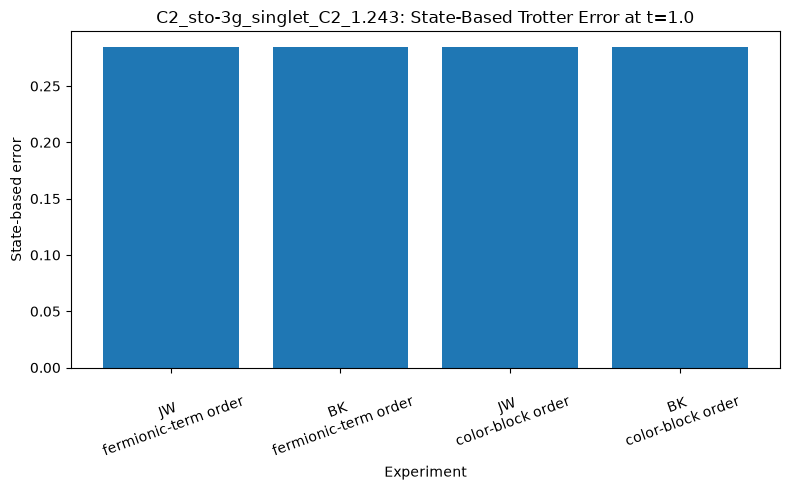


=== One-row molecular summary ===


,molecule,n_qubits,reference_electrons,fermionic_graph_vertices,fermionic_possible_pairs,fermionic_noncommuting_edges,fermionic_graph_density,fermionic_greedy_colors,fermionic_color_group_sizes,jw_pauli_graph_vertices,...,bk_fermionic_term_order_number_of_exponentials,bk_fermionic_term_order_runtime_seconds,jw_color_block_order_state_based_error,jw_color_block_order_state_infidelity,jw_color_block_order_number_of_exponentials,jw_color_block_order_runtime_seconds,bk_color_block_order_state_based_error,bk_color_block_order_state_infidelity,bk_color_block_order_number_of_exponentials,bk_color_block_order_runtime_seconds
0,C2_sto-3g_singlet_C2_1.243,20,12,656,214840,107184,0.498902,53,"[12, 12, 12, 12, 12, 12, 12, 12, 12, 12, 12, 12, 12, 12, 12, 14, 14, 12, 16, 12, 8, 12, 12, 12, 15, 23, 13, 7, 12, 12, 16, 14, 10, 12, 30, 10, 10, 8, 12, 12, 8, 10, 13, 13, 6, 26, 24, 10, 12, 10, 13, 2, 1]",1176,...,657,1943.887533,0.284357,0.073903,53,1314.442103,0.284357,0.073903,53,1181.194846



=== Structural interpretation ===
JW vertex expansion factor: 1.793
JW candidate-pair expansion factor: 3.216
JW greedy-color expansion factor: 0.491
JW Pauli-duplication ratio: 3.592
Result: the fermionic representation gives a smaller graph-search space than the JW Pauli representation.
The greedy color count does not show a clear fermionic advantage for this molecule.

=== Results saved successfully ===
Output folder: /Users/a_lee/Repos/qhat/fermionic_trotter_results/C2_sto-3g_singlet_C2_1.243
Saved: C2_sto-3g_singlet_C2_1.243_fermionic_state_errors.csv
Saved: C2_sto-3g_singlet_C2_1.243_fermionic_state_summary.csv
Saved: C2_sto-3g_singlet_C2_1.243_graph_structure_comparison.csv
Saved: C2_sto-3g_singlet_C2_1.243_structural_advantage.csv


2375

In [13]:
# New Cell 6:
# Final state-error results and structural comparison between
# the fermionic-term graph and the JW Pauli-string graph.
#
# The JW graph is analyzed without constructing a NetworkX graph.

import gc
import math
import re
import time

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


# ============================================================
# Settings
# ============================================================

FIXED_TIME = 1.0

# Largest-first greedy coloring is useful for comparing the number
# of fermionic groups with the number of JW Pauli groups.
COMPUTE_GREEDY_PAULI_COLORING = True

# Larger blocks use more memory but usually reduce Python overhead.
PAULI_PAIR_BLOCK_SIZE = 512

# The main comparison is fermionic terms versus JW Pauli strings.
# Set this to True only when you also want to verify the BK graph.
COMPUTE_BK_GRAPH_STATISTICS = False


# ============================================================
# Binary symplectic representation of Pauli strings
# ============================================================

def qubit_operator_to_symplectic_masks(
    qubit_operator,
    n_qubits,
    exclude_identity=True,
    atol=1.0e-12,
):
    """
    Convert each unique Pauli string into two uint64 masks.

    X-mask:
        bit q is 1 when the string has X or Y on qubit q.

    Z-mask:
        bit q is 1 when the string has Z or Y on qubit q.

    Two Pauli strings anticommute when

        parity(x1 & z2) XOR parity(z1 & x2) = 1.

    This implementation supports up to 63 qubits.
    """
    if n_qubits > 63:
        raise ValueError(
            "This fast uint64 implementation supports at most 63 qubits."
        )

    x_masks = []
    z_masks = []

    for pauli_term, coefficient in qubit_operator.terms.items():
        if abs(coefficient) <= atol:
            continue

        if exclude_identity and pauli_term == ():
            continue

        x_mask = np.uint64(0)
        z_mask = np.uint64(0)

        for qubit, pauli in pauli_term:
            bit = np.uint64(1) << np.uint64(qubit)

            if pauli == "X":
                x_mask |= bit

            elif pauli == "Y":
                x_mask |= bit
                z_mask |= bit

            elif pauli == "Z":
                z_mask |= bit

            else:
                raise ValueError(
                    f"Unknown Pauli symbol {pauli!r}."
                )

        x_masks.append(x_mask)
        z_masks.append(z_mask)

    return (
        np.asarray(x_masks, dtype=np.uint64),
        np.asarray(z_masks, dtype=np.uint64),
    )


def parity_uint64(values):
    """
    Calculate the bit-count parity of uint64 values.

    Returns 1 for odd parity and 0 for even parity.
    """
    values = np.asarray(values, dtype=np.uint64).copy()

    values ^= values >> np.uint64(32)
    values ^= values >> np.uint64(16)
    values ^= values >> np.uint64(8)
    values ^= values >> np.uint64(4)
    values ^= values >> np.uint64(2)
    values ^= values >> np.uint64(1)

    return values & np.uint64(1)


def pauli_anticommutation_block(
    x_left,
    z_left,
    x_right,
    z_right,
):
    """
    Return a Boolean matrix whose (i, j) entry is True when
    Pauli string i anticommutes with Pauli string j.
    """
    symplectic_products = np.bitwise_xor(
        np.bitwise_and(
            x_left[:, None],
            z_right[None, :],
        ),
        np.bitwise_and(
            z_left[:, None],
            x_right[None, :],
        ),
    )

    return parity_uint64(symplectic_products).astype(bool)


# ============================================================
# Exact graph statistics without NetworkX
# ============================================================

def calculate_pauli_graph_degrees_and_edges(
    x_masks,
    z_masks,
    block_size=512,
):
    """
    Calculate exact degrees and exact noncommuting-edge count
    without constructing a graph object or full adjacency matrix.

    Time complexity is still O(M^2), where M is the number of
    unique nonidentity Pauli strings.
    """
    number_of_vertices = len(x_masks)

    degrees = np.zeros(
        number_of_vertices,
        dtype=np.int64,
    )

    number_of_edges = 0

    if number_of_vertices <= 1:
        return degrees, number_of_edges

    for left_start in range(
        0,
        number_of_vertices,
        block_size,
    ):
        left_stop = min(
            left_start + block_size,
            number_of_vertices,
        )

        x_left = x_masks[left_start:left_stop]
        z_left = z_masks[left_start:left_stop]

        for right_start in range(
            left_start,
            number_of_vertices,
            block_size,
        ):
            right_stop = min(
                right_start + block_size,
                number_of_vertices,
            )

            x_right = x_masks[right_start:right_stop]
            z_right = z_masks[right_start:right_stop]

            anticommutes = pauli_anticommutation_block(
                x_left=x_left,
                z_left=z_left,
                x_right=x_right,
                z_right=z_right,
            )

            if left_start == right_start:
                # A Pauli string commutes with itself.
                np.fill_diagonal(anticommutes, False)

                block_degrees = anticommutes.sum(
                    axis=1,
                    dtype=np.int64,
                )

                degrees[
                    left_start:left_stop
                ] += block_degrees

                # The symmetric block counts every edge twice.
                number_of_edges += (
                    int(anticommutes.sum()) // 2
                )

            else:
                degrees[
                    left_start:left_stop
                ] += anticommutes.sum(
                    axis=1,
                    dtype=np.int64,
                )

                degrees[
                    right_start:right_stop
                ] += anticommutes.sum(
                    axis=0,
                    dtype=np.int64,
                )

                # A cross-block edge appears only once.
                number_of_edges += int(
                    anticommutes.sum()
                )

        print(
            "  Pair analysis:"
            f" {left_stop}/{number_of_vertices}"
            " Pauli strings processed"
        )

    return degrees, number_of_edges


# ============================================================
# Largest-first greedy coloring without NetworkX
# ============================================================

def greedy_largest_first_pauli_coloring(
    x_masks,
    z_masks,
    degrees,
):
    """
    Apply deterministic largest-degree-first greedy coloring.

    This gives a valid coloring and an upper bound on the
    chromatic number. It is not an exact minimum coloring.
    """
    number_of_vertices = len(x_masks)

    if number_of_vertices == 0:
        return (
            np.array([], dtype=int),
            [],
        )

    vertex_indices = np.arange(
        number_of_vertices,
        dtype=int,
    )

    # Primary key: decreasing degree.
    # Secondary key: increasing original index.
    coloring_order = np.lexsort(
        (
            vertex_indices,
            -degrees,
        )
    )

    colors = np.full(
        number_of_vertices,
        -1,
        dtype=int,
    )

    largest_color = -1

    for position, vertex in enumerate(coloring_order):
        if position == 0:
            colors[vertex] = 0
            largest_color = 0
            continue

        previous_vertices = coloring_order[:position]

        symplectic_products = np.bitwise_xor(
            np.bitwise_and(
                x_masks[vertex],
                z_masks[previous_vertices],
            ),
            np.bitwise_and(
                z_masks[vertex],
                x_masks[previous_vertices],
            ),
        )

        anticommutes = parity_uint64(
            symplectic_products
        ).astype(bool)

        forbidden_colors = colors[
            previous_vertices[anticommutes]
        ]

        # Add one extra slot so that a new color is always available.
        used = np.zeros(
            largest_color + 2,
            dtype=bool,
        )

        if len(forbidden_colors) > 0:
            used[forbidden_colors] = True

        available_colors = np.flatnonzero(~used)
        chosen_color = int(available_colors[0])

        colors[vertex] = chosen_color
        largest_color = max(
            largest_color,
            chosen_color,
        )

        if (
            (position + 1) % 1000 == 0
            or position + 1 == number_of_vertices
        ):
            print(
                "  Coloring:"
                f" {position + 1}/{number_of_vertices}"
                " Pauli strings processed"
            )

    color_group_sizes = np.bincount(
        colors,
        minlength=largest_color + 1,
    ).tolist()

    return colors, color_group_sizes


def calculate_pauli_graph_statistics(
    qubit_operator,
    n_qubits,
    mapping_label,
    block_size=512,
    compute_coloring=True,
):
    """
    Calculate Pauli noncommutation-graph statistics without NetworkX.
    """
    total_start = time.perf_counter()

    x_masks, z_masks = qubit_operator_to_symplectic_masks(
        qubit_operator=qubit_operator,
        n_qubits=n_qubits,
        exclude_identity=True,
    )

    number_of_vertices = len(x_masks)
    number_of_possible_pairs = (
        number_of_vertices
        * (number_of_vertices - 1)
        // 2
    )

    print()
    print(
        f"=== Calculating {mapping_label} Pauli graph ==="
    )
    print(
        "Unique nonidentity Pauli strings:",
        number_of_vertices,
    )
    print(
        "Possible unordered pairs:",
        number_of_possible_pairs,
    )

    pair_start = time.perf_counter()

    degrees, number_of_edges = (
        calculate_pauli_graph_degrees_and_edges(
            x_masks=x_masks,
            z_masks=z_masks,
            block_size=block_size,
        )
    )

    pair_runtime = time.perf_counter() - pair_start

    if number_of_possible_pairs > 0:
        graph_density = (
            number_of_edges
            / number_of_possible_pairs
        )
    else:
        graph_density = 0.0

    if number_of_vertices > 0:
        average_degree = float(
            degrees.mean()
        )
        maximum_degree = int(
            degrees.max()
        )
    else:
        average_degree = 0.0
        maximum_degree = 0

    if compute_coloring:
        coloring_start = time.perf_counter()

        colors, color_group_sizes = (
            greedy_largest_first_pauli_coloring(
                x_masks=x_masks,
                z_masks=z_masks,
                degrees=degrees,
            )
        )

        coloring_runtime = (
            time.perf_counter()
            - coloring_start
        )

        number_of_colors = (
            int(colors.max()) + 1
            if len(colors) > 0
            else 0
        )

    else:
        coloring_runtime = np.nan
        number_of_colors = np.nan
        color_group_sizes = []

    total_runtime = time.perf_counter() - total_start

    return {
        "representation": f"{mapping_label} Pauli strings",
        "number_of_vertices": number_of_vertices,
        "number_of_possible_pairs": number_of_possible_pairs,
        "number_of_noncommuting_edges": number_of_edges,
        "graph_density": graph_density,
        "average_degree": average_degree,
        "maximum_degree": maximum_degree,
        "largest_first_greedy_colors": number_of_colors,
        "color_group_sizes": str(color_group_sizes),
        "pair_analysis_runtime_seconds": pair_runtime,
        "coloring_runtime_seconds": coloring_runtime,
        "total_graph_runtime_seconds": total_runtime,
    }


# ============================================================
# Fermionic graph statistics
# ============================================================

def is_identity_fermion_operator(operator, atol=1.0e-12):
    """
    Return True when the operator contains only an identity term.
    """
    surviving_terms = [
        term
        for term, coefficient in operator.terms.items()
        if abs(coefficient) > atol
    ]

    return (
        len(surviving_terms) == 1
        and surviving_terms[0] == ()
    )


def get_graph_fermionic_operator(node):
    """
    Recover the FermionOperator stored at a graph node.
    """
    if "operator" in G.nodes[node]:
        return G.nodes[node]["operator"]

    return hermitian_terms[node]


fermionic_nonidentity_nodes = [
    node
    for node in G.nodes
    if not is_identity_fermion_operator(
        get_graph_fermionic_operator(node)
    )
]

fermionic_number_of_vertices = len(
    fermionic_nonidentity_nodes
)

fermionic_number_of_possible_pairs = (
    fermionic_number_of_vertices
    * (fermionic_number_of_vertices - 1)
    // 2
)

# Removing the identity does not remove any noncommuting edges.
fermionic_number_of_edges = G.number_of_edges()

if fermionic_number_of_possible_pairs > 0:
    fermionic_graph_density = (
        fermionic_number_of_edges
        / fermionic_number_of_possible_pairs
    )
else:
    fermionic_graph_density = 0.0


# Color-group sizes after excluding the identity term.
fermionic_color_group_sizes = []

for color in sorted(color_groups):
    nonidentity_count = sum(
        not is_identity_fermion_operator(
            get_graph_fermionic_operator(node)
        )
        for node in color_groups[color]
    )

    if nonidentity_count > 0:
        fermionic_color_group_sizes.append(
            nonidentity_count
        )

fermionic_number_of_colors = len(
    fermionic_color_group_sizes
)

fermionic_average_degree = (
    2.0
    * fermionic_number_of_edges
    / fermionic_number_of_vertices
    if fermionic_number_of_vertices > 0
    else 0.0
)


# ============================================================
# Calculate JW Pauli graph statistics
# ============================================================

jw_graph_statistics = calculate_pauli_graph_statistics(
    qubit_operator=H_JW,
    n_qubits=n_qubits,
    mapping_label="JW",
    block_size=PAULI_PAIR_BLOCK_SIZE,
    compute_coloring=COMPUTE_GREEDY_PAULI_COLORING,
)


# BK is optional because the JW and BK analyses approximately
# double the graph-statistics runtime.
bk_graph_statistics = None

if COMPUTE_BK_GRAPH_STATISTICS:
    bk_graph_statistics = calculate_pauli_graph_statistics(
        qubit_operator=H_BK,
        n_qubits=n_qubits,
        mapping_label="BK",
        block_size=PAULI_PAIR_BLOCK_SIZE,
        compute_coloring=COMPUTE_GREEDY_PAULI_COLORING,
    )


# ============================================================
# Graph-structure comparison table
# ============================================================

fermionic_graph_statistics = {
    "representation": "Hermitian fermionic terms",
    "number_of_vertices": fermionic_number_of_vertices,
    "number_of_possible_pairs": (
        fermionic_number_of_possible_pairs
    ),
    "number_of_noncommuting_edges": (
        fermionic_number_of_edges
    ),
    "graph_density": fermionic_graph_density,
    "average_degree": fermionic_average_degree,
    "maximum_degree": np.nan,
    "largest_first_greedy_colors": (
        fermionic_number_of_colors
    ),
    "color_group_sizes": str(
        fermionic_color_group_sizes
    ),
    "pair_analysis_runtime_seconds": np.nan,
    "coloring_runtime_seconds": np.nan,
    "total_graph_runtime_seconds": np.nan,
}

graph_rows = [
    fermionic_graph_statistics,
    jw_graph_statistics,
]

if bk_graph_statistics is not None:
    graph_rows.append(bk_graph_statistics)

graph_structure_comparison_df = pd.DataFrame(
    graph_rows
)

print()
print("=== Noncommutation graph structure comparison ===")

display(
    graph_structure_comparison_df[
        [
            "representation",
            "number_of_vertices",
            "number_of_possible_pairs",
            "number_of_noncommuting_edges",
            "graph_density",
            "average_degree",
            "largest_first_greedy_colors",
            "color_group_sizes",
            "total_graph_runtime_seconds",
        ]
    ]
)


# ============================================================
# JW Pauli expansion and duplication statistics
# ============================================================

def count_nonidentity_pauli_terms(qubit_operator):
    return sum(
        1
        for pauli_term, coefficient
        in qubit_operator.terms.items()
        if (
            pauli_term != ()
            and abs(coefficient) > 1.0e-12
        )
    )


# Number of Pauli strings before combining duplicates generated
# by different fermionic terms.
jw_uncombined_nonidentity_count = sum(
    count_nonidentity_pauli_terms(mapped_term)
    for mapped_term in JW_fermionic_term_order
)

# Number of unique Pauli strings after combining the full Hamiltonian.
jw_unique_nonidentity_count = (
    jw_graph_statistics["number_of_vertices"]
)

if jw_unique_nonidentity_count > 0:
    jw_pauli_duplication_ratio = (
        jw_uncombined_nonidentity_count
        / jw_unique_nonidentity_count
    )
else:
    jw_pauli_duplication_ratio = np.nan


# ============================================================
# Structural-advantage metrics
# ============================================================

def safe_ratio(numerator, denominator):
    if denominator == 0:
        return np.nan

    return numerator / denominator


vertex_expansion_factor = safe_ratio(
    jw_graph_statistics["number_of_vertices"],
    fermionic_number_of_vertices,
)

pair_search_expansion_factor = safe_ratio(
    jw_graph_statistics["number_of_possible_pairs"],
    fermionic_number_of_possible_pairs,
)

edge_expansion_factor = safe_ratio(
    jw_graph_statistics[
        "number_of_noncommuting_edges"
    ],
    fermionic_number_of_edges,
)

color_expansion_factor = safe_ratio(
    jw_graph_statistics[
        "largest_first_greedy_colors"
    ],
    fermionic_number_of_colors,
)

pair_search_reduction_fraction = (
    1.0
    - safe_ratio(
        fermionic_number_of_possible_pairs,
        jw_graph_statistics[
            "number_of_possible_pairs"
        ],
    )
)

structural_advantage_df = pd.DataFrame(
    [
        {
            "molecule": MOLECULE_LABEL,
            "fermionic_graph_vertices": (
                fermionic_number_of_vertices
            ),
            "jw_pauli_graph_vertices": (
                jw_graph_statistics[
                    "number_of_vertices"
                ]
            ),
            "jw_vertex_expansion_factor": (
                vertex_expansion_factor
            ),
            "fermionic_candidate_pairs": (
                fermionic_number_of_possible_pairs
            ),
            "jw_candidate_pairs": (
                jw_graph_statistics[
                    "number_of_possible_pairs"
                ]
            ),
            "jw_pair_search_expansion_factor": (
                pair_search_expansion_factor
            ),
            "fermionic_noncommuting_edges": (
                fermionic_number_of_edges
            ),
            "jw_noncommuting_edges": (
                jw_graph_statistics[
                    "number_of_noncommuting_edges"
                ]
            ),
            "jw_edge_expansion_factor": (
                edge_expansion_factor
            ),
            "fermionic_greedy_colors": (
                fermionic_number_of_colors
            ),
            "jw_greedy_colors": (
                jw_graph_statistics[
                    "largest_first_greedy_colors"
                ]
            ),
            "jw_color_expansion_factor": (
                color_expansion_factor
            ),
            "pair_search_reduction_using_fermions": (
                pair_search_reduction_fraction
            ),
            "jw_uncombined_pauli_strings": (
                jw_uncombined_nonidentity_count
            ),
            "jw_unique_pauli_strings": (
                jw_unique_nonidentity_count
            ),
            "jw_pauli_duplication_ratio": (
                jw_pauli_duplication_ratio
            ),
        }
    ]
)

print()
print("=== Fermionic structural-advantage metrics ===")
display(structural_advantage_df)


# ============================================================
# Fixed-time state-based error table
# ============================================================

fixed_time_df = fermionic_state_error_df[
    np.isclose(
        fermionic_state_error_df["time_t"],
        FIXED_TIME,
    )
].copy()

if fixed_time_df.empty:
    available_times = sorted(
        fermionic_state_error_df[
            "time_t"
        ].unique()
    )

    FIXED_TIME = available_times[-1]

    fixed_time_df = fermionic_state_error_df[
        np.isclose(
            fermionic_state_error_df["time_t"],
            FIXED_TIME,
        )
    ].copy()


print()
print(
    f"=== State-based Trotter error at t = "
    f"{FIXED_TIME} ==="
)

display(
    fixed_time_df[
        [
            "mapping",
            "ordering",
            "number_of_exponentials",
            "state_based_error",
            "state_infidelity",
            "trotter_runtime_seconds",
        ]
    ].sort_values(
        [
            "mapping",
            "ordering",
        ]
    )
)


# ============================================================
# State-error plot
# ============================================================

plt.figure(figsize=(8, 5))

if fermionic_state_error_df["time_t"].nunique() > 1:
    for (
        mapping,
        ordering,
    ), group in fermionic_state_error_df.groupby(
        [
            "mapping",
            "ordering",
        ]
    ):
        group = group.sort_values("time_t")

        plt.plot(
            group["time_t"],
            group["state_based_error"],
            marker="o",
            label=f"{mapping}, {ordering}",
        )

    plt.xlabel("Time t")
    plt.ylabel("State-based error")
    plt.title(
        f"{MOLECULE_LABEL}: "
        "State-Based Trotter Error vs Time"
    )
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

else:
    plotting_df = fixed_time_df.copy()

    plotting_df["experiment"] = (
        plotting_df["mapping"]
        + "\n"
        + plotting_df["ordering"]
    )

    plt.bar(
        plotting_df["experiment"],
        plotting_df["state_based_error"],
    )

    plt.xlabel("Experiment")
    plt.ylabel("State-based error")
    plt.title(
        f"{MOLECULE_LABEL}: "
        f"State-Based Trotter Error at "
        f"t={FIXED_TIME}"
    )
    plt.xticks(rotation=20)
    plt.tight_layout()
    plt.show()


# ============================================================
# One-row molecular summary
# ============================================================

summary_row = {
    "molecule": MOLECULE_LABEL,
    "n_qubits": n_qubits,
    "reference_electrons": n_reference_electrons,

    # Fermionic graph
    "fermionic_graph_vertices": (
        fermionic_number_of_vertices
    ),
    "fermionic_possible_pairs": (
        fermionic_number_of_possible_pairs
    ),
    "fermionic_noncommuting_edges": (
        fermionic_number_of_edges
    ),
    "fermionic_graph_density": (
        fermionic_graph_density
    ),
    "fermionic_greedy_colors": (
        fermionic_number_of_colors
    ),
    "fermionic_color_group_sizes": str(
        fermionic_color_group_sizes
    ),

    # JW Pauli graph
    "jw_pauli_graph_vertices": (
        jw_graph_statistics[
            "number_of_vertices"
        ]
    ),
    "jw_pauli_possible_pairs": (
        jw_graph_statistics[
            "number_of_possible_pairs"
        ]
    ),
    "jw_pauli_noncommuting_edges": (
        jw_graph_statistics[
            "number_of_noncommuting_edges"
        ]
    ),
    "jw_pauli_graph_density": (
        jw_graph_statistics[
            "graph_density"
        ]
    ),
    "jw_pauli_greedy_colors": (
        jw_graph_statistics[
            "largest_first_greedy_colors"
        ]
    ),
    "jw_pauli_color_group_sizes": (
        jw_graph_statistics[
            "color_group_sizes"
        ]
    ),

    # Structural advantage
    "jw_vertex_expansion_factor": (
        vertex_expansion_factor
    ),
    "jw_pair_search_expansion_factor": (
        pair_search_expansion_factor
    ),
    "jw_edge_expansion_factor": (
        edge_expansion_factor
    ),
    "jw_color_expansion_factor": (
        color_expansion_factor
    ),
    "pair_search_reduction_using_fermions": (
        pair_search_reduction_fraction
    ),
    "jw_pauli_duplication_ratio": (
        jw_pauli_duplication_ratio
    ),

    # Experiment settings
    "fixed_time_t": FIXED_TIME,
    "trotter_steps": N_TROTTER_STEPS,
}


for _, row in fixed_time_df.iterrows():
    mapping_tag = row["mapping"].lower()

    ordering_tag = (
        row["ordering"]
        .lower()
        .replace("-", "_")
        .replace(" ", "_")
    )

    prefix = (
        f"{mapping_tag}_{ordering_tag}"
    )

    summary_row[
        f"{prefix}_state_based_error"
    ] = row["state_based_error"]

    summary_row[
        f"{prefix}_state_infidelity"
    ] = row["state_infidelity"]

    summary_row[
        f"{prefix}_number_of_exponentials"
    ] = row["number_of_exponentials"]

    summary_row[
        f"{prefix}_runtime_seconds"
    ] = row["trotter_runtime_seconds"]


molecule_state_summary_df = pd.DataFrame(
    [summary_row]
)

print()
print("=== One-row molecular summary ===")
display(molecule_state_summary_df)


# ============================================================
# Simple structural interpretation
# ============================================================

print()
print("=== Structural interpretation ===")

print(
    "JW vertex expansion factor:",
    f"{vertex_expansion_factor:.3f}"
)

print(
    "JW candidate-pair expansion factor:",
    f"{pair_search_expansion_factor:.3f}"
)

print(
    "JW greedy-color expansion factor:",
    f"{color_expansion_factor:.3f}"
)

print(
    "JW Pauli-duplication ratio:",
    f"{jw_pauli_duplication_ratio:.3f}"
)

if (
    vertex_expansion_factor > 1.0
    and pair_search_expansion_factor > 1.0
):
    print(
        "Result: the fermionic representation gives a "
        "smaller graph-search space than the JW Pauli "
        "representation."
    )
else:
    print(
        "Result: this molecule does not show a clear "
        "fermionic graph-size advantage."
    )

if (
    COMPUTE_GREEDY_PAULI_COLORING
    and color_expansion_factor > 1.0
):
    print(
        "The JW Pauli graph also requires more greedy "
        "color groups than the fermionic graph."
    )
elif COMPUTE_GREEDY_PAULI_COLORING:
    print(
        "The greedy color count does not show a clear "
        "fermionic advantage for this molecule."
    )


# ============================================================
# Export results into an organized molecule folder
# ============================================================

from pathlib import Path


safe_molecule_label = re.sub(
    r"[^A-Za-z0-9_.-]+",
    "_",
    MOLECULE_LABEL,
).strip("_")

if not safe_molecule_label:
    safe_molecule_label = "molecule"


# Main folder for all eleven molecular experiments
output_root = Path("fermionic_trotter_results")

# Separate folder for the current molecule
output_folder = output_root / safe_molecule_label

output_folder.mkdir(
    parents=True,
    exist_ok=True,
)


# ------------------------------------------------------------
# Output filenames
# ------------------------------------------------------------

time_output_file = (
    output_folder
    / f"{safe_molecule_label}_fermionic_state_errors.csv"
)

summary_output_file = (
    output_folder
    / f"{safe_molecule_label}_fermionic_state_summary.csv"
)

graph_output_file = (
    output_folder
    / f"{safe_molecule_label}_graph_structure_comparison.csv"
)

advantage_output_file = (
    output_folder
    / f"{safe_molecule_label}_structural_advantage.csv"
)


# ------------------------------------------------------------
# Save CSV files
# ------------------------------------------------------------

fermionic_state_error_df.to_csv(
    time_output_file,
    index=False,
)

molecule_state_summary_df.to_csv(
    summary_output_file,
    index=False,
)

graph_structure_comparison_df.to_csv(
    graph_output_file,
    index=False,
)

structural_advantage_df.to_csv(
    advantage_output_file,
    index=False,
)


print()
print("=== Results saved successfully ===")
print("Output folder:", output_folder.resolve())
print("Saved:", time_output_file.name)
print("Saved:", summary_output_file.name)
print("Saved:", graph_output_file.name)
print("Saved:", advantage_output_file.name)

gc.collect()

## Structural Comparison: Fermionic-Term Graph vs. JW Pauli-String Graph

Let

- $V_F$: number of nonidentity Hermitian fermionic terms,
- $V_{\mathrm{JW}}$: number of unique nonidentity JW Pauli strings,
- $E_F$: number of noncommuting fermionic-term pairs,
- $E_{\mathrm{JW}}$: number of noncommuting JW Pauli-string pairs,
- $C_F$: number of greedy colors for the fermionic graph,
- $C_{\mathrm{JW}}$: number of greedy colors for the JW graph.

---

### 1. Number of Candidate Pairs

For a graph with $V$ vertices, the number of possible unordered vertex pairs is

$$
P(V)
=
\binom{V}{2}
=
\frac{V(V-1)}{2}.
$$

Therefore, the number of candidate commutation tests for the fermionic graph is

$$
P_F
=
\binom{V_F}{2}
=
\frac{V_F(V_F-1)}{2},
$$

while the number of candidate commutation tests for the JW Pauli-string graph is

$$
P_{\mathrm{JW}}
=
\binom{V_{\mathrm{JW}}}{2}
=
\frac{V_{\mathrm{JW}}(V_{\mathrm{JW}}-1)}{2}.
$$

---

### 2. JW Vertex-Expansion Factor

The increase in the number of graph vertices after Jordan-Wigner mapping is measured by

$$
R_V
=
\frac{V_{\mathrm{JW}}}{V_F}.
$$

Interpretation:

- $R_V>1$: the JW Pauli graph has more vertices.
- $R_V=1$: the two graphs have the same number of vertices.
- $R_V<1$: the JW Pauli graph has fewer vertices.

---

### 3. JW Candidate-Pair Expansion Factor

The increase in the number of possible pairwise commutation tests is

$$
R_P
=
\frac{P_{\mathrm{JW}}}{P_F}
=
\frac{\binom{V_{\mathrm{JW}}}{2}}
     {\binom{V_F}{2}}.
$$

Equivalently,

$$
R_P
=
\frac{
V_{\mathrm{JW}}(V_{\mathrm{JW}}-1)
}{
V_F(V_F-1)
}.
$$

For sufficiently large graphs,

$$
R_P
\approx
\left(
\frac{V_{\mathrm{JW}}}{V_F}
\right)^2
=
R_V^2.
$$

Thus, a vertex-expansion factor of approximately $R_V$ can produce a candidate-pair expansion factor of approximately $R_V^2$.

---

### 4. Pair-Search Reduction from Using Fermionic Terms

The fractional reduction in candidate-pair comparisons obtained by using the fermionic graph instead of the JW graph is

$$
S_P
=
1-\frac{P_F}{P_{\mathrm{JW}}}.
$$

The corresponding percentage reduction is

$$
100S_P\%.
$$

Interpretation:

- $S_P>0$: the fermionic representation requires fewer candidate-pair checks.
- $S_P=0$: both representations require the same number of checks.
- $S_P<0$: the fermionic representation requires more candidate-pair checks.

---

### 5. Noncommuting-Edge Expansion Factor

The increase in the number of actual noncommuting pairs is

$$
R_E
=
\frac{E_{\mathrm{JW}}}{E_F}.
$$

This quantity compares the number of actual graph edges rather than the number of possible vertex pairs.

Interpretation:

- $R_E>1$: the JW graph has more noncommuting edges.
- $R_E=1$: both graphs have the same number of noncommuting edges.
- $R_E<1$: the fermionic graph has more noncommuting edges.

---

### 6. Graph Density

For a graph with $V$ vertices and $E$ noncommuting edges, the graph density is

$$
D
=
\frac{E}{\binom{V}{2}}
=
\frac{2E}{V(V-1)}.
$$

Therefore, the fermionic graph density is

$$
D_F
=
\frac{E_F}{\binom{V_F}{2}}
=
\frac{2E_F}{V_F(V_F-1)},
$$

and the JW graph density is

$$
D_{\mathrm{JW}}
=
\frac{E_{\mathrm{JW}}}
     {\binom{V_{\mathrm{JW}}}{2}}
=
\frac{2E_{\mathrm{JW}}}
     {V_{\mathrm{JW}}(V_{\mathrm{JW}}-1)}.
$$

Graph density measures the fraction of all possible pairs that do not commute.

---

### 7. Average Degree

The average degree of an undirected noncommutation graph is

$$
\bar{d}
=
\frac{2E}{V}.
$$

Therefore,

$$
\bar{d}_F
=
\frac{2E_F}{V_F},
$$

and

$$
\bar{d}_{\mathrm{JW}}
=
\frac{2E_{\mathrm{JW}}}{V_{\mathrm{JW}}}.
$$

The average degree gives the average number of noncommuting neighbors per graph vertex.

---

### 8. Greedy-Color Expansion Factor

The increase in the number of commuting groups produced by the same greedy-coloring rule is

$$
R_C
=
\frac{C_{\mathrm{JW}}}{C_F}.
$$

Interpretation:

- $R_C>1$: the JW graph requires more greedy color groups.
- $R_C=1$: both graphs use the same number of greedy colors.
- $R_C<1$: the JW graph uses fewer greedy colors.

The greedy color count is an upper bound produced by the selected heuristic. It is not necessarily equal to the exact chromatic number.

---

### 9. JW Pauli-Duplication Ratio

Suppose the fermionic Hamiltonian is decomposed as

$$
H
=
\sum_{\alpha} H_{\alpha},
$$

where each $H_{\alpha}$ is a Hermitian fermionic term.

Let

$$
N_{\mathrm{JW}}^{\mathrm{uncombined}}
=
\sum_{\alpha}
\#\mathrm{JW}(H_{\alpha})
$$

be the total number of JW Pauli strings before combining duplicates generated by different fermionic terms.

Let

$$
N_{\mathrm{JW}}^{\mathrm{unique}}
=
\#\mathrm{JW}(H)
$$

be the number of unique Pauli strings after combining the complete mapped Hamiltonian.

The JW Pauli-duplication ratio is

$$
R_{\mathrm{dup}}
=
\frac{
N_{\mathrm{JW}}^{\mathrm{uncombined}}
}{
N_{\mathrm{JW}}^{\mathrm{unique}}
}
\geq 1.
$$

Interpretation:

- $R_{\mathrm{dup}}=1$: no Pauli strings are duplicated across the mapped fermionic terms.
- $R_{\mathrm{dup}}>1$: some Pauli strings are generated by multiple fermionic terms.
- A larger value indicates greater duplication before the mapped Hamiltonian is simplified.

---

### 10. State-Based Trotter Error

For an initial state $|\psi_0\rangle$, the state-based Trotter error is

$$
\epsilon_{\mathrm{state}}(t)
=
\left\|
U_{\mathrm{Trotter}}(t)|\psi_0\rangle
-
U_{\mathrm{exact}}(t)|\psi_0\rangle
\right\|_2,
$$

where

$$
U_{\mathrm{exact}}(t)
=
e^{-itH}.
$$

The exact evolved state is

$$
|\psi_{\mathrm{exact}}(t)\rangle
=
U_{\mathrm{exact}}(t)|\psi_0\rangle,
$$

and the Trotter-evolved state is

$$
|\psi_{\mathrm{Trotter}}(t)\rangle
=
U_{\mathrm{Trotter}}(t)|\psi_0\rangle.
$$

The corresponding state infidelity is

$$
\epsilon_{\mathrm{infidelity}}(t)
=
1-
\left|
\langle
\psi_{\mathrm{exact}}(t)
|
\psi_{\mathrm{Trotter}}(t)
\rangle
\right|^2.
$$

---

### 11. Structural-Advantage Conditions

Evidence for a fermionic structural advantage is obtained when one or more of the following conditions hold:

$$
R_V>1,
\qquad
R_P>1,
\qquad
R_E>1,
\qquad
R_C>1.
$$

In particular,

$$
R_P>1
$$

shows that the fermionic representation has a smaller pairwise commutation-search space than the JW Pauli-string representation.

However, a smaller graph does not automatically imply a smaller Trotter error. The structural metrics should therefore be evaluated together with

$$
\epsilon_{\mathrm{state}}(t),
$$

the state infidelity, and the number of exponentials required by each product formula.

---

### 12. Main Interpretation

The fermionic representation provides a useful structural advantage when it produces

- fewer graph vertices,
- fewer candidate commutation pairs,
- fewer noncommuting edges,
- fewer greedy color groups,
- or a smaller classical preprocessing problem.

The most direct classical-search advantage is measured by

$$
R_P
=
\frac{P_{\mathrm{JW}}}{P_F}.
$$

The practical Trotterization advantage must additionally be evaluated using the state-based error and the number of exponentials.